# Análisis y Predicción de Precios de Vehículos Usados

**Institución Universitaria de Envigado 

**Integrantes:** Natalia Flores Pérez · Santiago Arcila Gutiérrez · Alejandro Restrepo Uribe

**Dataset:** *Vehicle Dataset from CarDekho* — archivo `Car details v3.csv`
https://www.kaggle.com/datasets/nehalbirla/vehicle-dataset-from-cardekho

---

### Cómo está organizado este notebook

Cada sección corresponde a una de las siete tareas del enunciado. Antes de cada bloque de
código hay una celda de texto que explica **qué se hace y por qué**, porque la rúbrica evalúa
la justificación de las decisiones tanto como la implementación.

| Tarea | Contenido |
|---|---|
| 1 | Exploración de datos y reflexión de negocio previa |
| 2 | Ingeniería de características |
| 3 | Clasificación en rangos de precio |
| 4 | Regresión lineal, Ridge y Lasso |
| 5 | Árboles de decisión y modelos de ensamble |
| 6 | Optimización de hiperparámetros y validación cruzada |
| 7 | Visualización y conclusiones no técnicas |

### Tres decisiones metodológicas que atraviesan todo el trabajo

1. **La partición train/test se hace antes de cualquier otra cosa.** Los cortes que definen las
   categorías de precio se calculan únicamente sobre el conjunto de entrenamiento. Calcularlos
   sobre el dataset completo filtraría información del test hacia el entrenamiento.
2. **Todo el preprocesamiento vive dentro de un `Pipeline`.** Al usar `Pipeline` +
   `ColumnTransformer`, el escalador y el codificador se reajustan en cada pliegue de la
   validación cruzada. Escalar el dataset completo antes de validar es el error más frecuente
   en este tipo de ejercicio y produce métricas artificialmente optimistas.
3. **La variable objetivo se modela en escala logarítmica.** El precio tiene una cola derecha
   muy pronunciada; más abajo se muestra cuánto cambia el desempeño de la regresión lineal por
   esta única decisión. Las métricas, eso sí, se reportan siempre en rupias.

In [1]:
# ============================================================
# Configuración e importaciones
# ============================================================
import warnings, re
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import (train_test_split, GridSearchCV,
                                     RandomizedSearchCV, cross_val_score,
                                     StratifiedKFold, KFold)
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.linear_model import LinearRegression, Ridge, Lasso, LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import (DecisionTreeRegressor, DecisionTreeClassifier, plot_tree)
from sklearn.ensemble import (RandomForestRegressor, RandomForestClassifier,
                              GradientBoostingRegressor, GradientBoostingClassifier)
from sklearn.metrics import (mean_squared_error, r2_score, accuracy_score,
                             precision_score, recall_score, f1_score,
                             classification_report, confusion_matrix,
                             ConfusionMatrixDisplay)
from sklearn.inspection import permutation_importance

RANDOM_STATE = 42           # semilla única para que todo el notebook sea reproducible
ANIO_REFERENCIA = 2020      # el dataset fue recolectado hasta 2020; define la antigüedad

sns.set_theme(style='whitegrid', palette='deep')
plt.rcParams['figure.dpi'] = 110
pd.set_option('display.width', 160)
pd.set_option('display.max_columns', 40)

print('Entorno listo.')

Entorno listo.


---
# Tarea 1 · Exploración de Datos

Objetivo de esta sección: entender qué contiene el dataset, cuánta suciedad tiene y con qué
criterio se va a limpiar. Ninguna fila se elimina en esta tarea: aquí solo se diagnostica.
La limpieza efectiva se ejecuta en la Tarea 2, ya con los criterios justificados.

In [2]:
# ------------------------------------------------------------
# 1.1 Carga del dataset
# ------------------------------------------------------------
RUTA = 'Car details v3.csv'   # el archivo debe estar en la misma carpeta que el notebook

df_raw = pd.read_csv(RUTA)

print(f'Filas: {df_raw.shape[0]}   Columnas: {df_raw.shape[1]}')
df_raw.head()

Filas: 8128   Columnas: 13


,name,year,selling_price,km_driven,fuel,seller_type,transmission,owner,mileage,engine,max_power,torque,seats
0,Maruti Swift Dzire VDI,2014,450000,145500,Diesel,Individual,Manual,First Owner,23.4 kmpl,1248 CC,74 bhp,190Nm@ 2000rpm,5.0
1,Skoda Rapid 1.5 TDI Ambition,2014,370000,120000,Diesel,Individual,Manual,Second Owner,21.14 kmpl,1498 CC,103.52 bhp,250Nm@ 1500-2500rpm,5.0
2,Honda City 2017-2020 EXi,2006,158000,140000,Petrol,Individual,Manual,Third Owner,17.7 kmpl,1497 CC,78 bhp,"12.7@ 2,700(kgm@ rpm)",5.0
3,Hyundai i20 Sportz Diesel,2010,225000,127000,Diesel,Individual,Manual,First Owner,23.0 kmpl,1396 CC,90 bhp,22.4 kgm at 1750-2750rpm,5.0
4,Maruti Swift VXI BSIII,2007,130000,120000,Petrol,Individual,Manual,First Owner,16.1 kmpl,1298 CC,88.2 bhp,"11.5@ 4,500(kgm@ rpm)",5.0


In [3]:
# ------------------------------------------------------------
# 1.2 Tipos de dato y diccionario de variables
# ------------------------------------------------------------
diccionario = pd.DataFrame({
    'variable': df_raw.columns,
    'tipo_pandas': [str(t) for t in df_raw.dtypes],
    'nulos': df_raw.isna().sum().values,
    'valores_unicos': [df_raw[c].nunique() for c in df_raw.columns],
    'ejemplo': [df_raw[c].dropna().iloc[0] for c in df_raw.columns],
})
diccionario

,variable,tipo_pandas,nulos,valores_unicos,ejemplo
0,name,str,0,2058,Maruti Swift Dzire VDI
1,year,int64,0,29,2014
2,selling_price,int64,0,677,450000
3,km_driven,int64,0,921,145500
4,fuel,str,0,4,Diesel
5,seller_type,str,0,3,Individual
6,transmission,str,0,2,Manual
7,owner,str,0,5,First Owner
8,mileage,str,221,393,23.4 kmpl
9,engine,str,221,121,1248 CC


### Primer hallazgo importante

Cinco variables que deberían ser numéricas están almacenadas como texto: `mileage`, `engine`,
`max_power` y `torque` vienen con la unidad pegada al número (`"23.4 kmpl"`, `"1248 CC"`,
`"74 bhp"`, `"190Nm@ 2000rpm"`).

Si se ignoran, se pierden justo las variables que describen las características mecánicas del
vehículo, que son las que más deberían explicar el precio. Recuperarlas es el trabajo central
de la Tarea 2.

In [4]:
# ------------------------------------------------------------
# 1.3 Valores nulos y duplicados
# ------------------------------------------------------------
print('Valores nulos por columna:')
print(df_raw.isna().sum()[df_raw.isna().sum() > 0])

print(f'\nFilas duplicadas exactas: {df_raw.duplicated().sum()}'
      f'  ({df_raw.duplicated().mean():.1%} del dataset)')

# ¿Los nulos están concentrados en las mismas filas?
mask_nulos = df_raw[['mileage','engine','max_power','torque','seats']].isna().any(axis=1)
print(f'Filas con al menos un nulo en las columnas técnicas: {mask_nulos.sum()}')
print(f'Filas con TODAS esas columnas nulas: '
      f'{df_raw[["mileage","engine","max_power","torque","seats"]].isna().all(axis=1).sum()}')

Valores nulos por columna:
mileage      221
engine       221
max_power    215
torque       222
seats        221
dtype: int64

Filas duplicadas exactas: 1202  (14.8% del dataset)
Filas con al menos un nulo en las columnas técnicas: 222
Filas con TODAS esas columnas nulas: 215


Los nulos no están dispersos: son prácticamente **el mismo bloque de filas** al que le falta
toda la ficha técnica. Eso cambia la decisión de tratamiento. Imputar una variable aislada es
razonable; imputar cinco variables a la vez para la misma fila equivale a inventar el vehículo
completo. Como esas filas son cerca del 3% del dataset, la decisión será **eliminarlas**, y así
queda documentado.

Los duplicados exactos, en cambio, sí son un problema serio: alrededor de 1.200 filas (≈15%).
Al ser réplicas idénticas, si una copia queda en entrenamiento y otra en prueba, el modelo
"predice" un registro que ya vio. Se eliminan antes de partir los datos.

In [5]:
# ------------------------------------------------------------
# 1.4 Estadísticos descriptivos
# ------------------------------------------------------------
df_raw[['year','selling_price','km_driven','seats']].describe().T

,count,mean,std,min,25%,50%,75%,max
year,8128.0,2013.804011,4.044249,1983.0,2011.0,2015.0,2017.0,2020.0
selling_price,8128.0,638271.807702,806253.403508,29999.0,254999.0,450000.0,675000.0,10000000.0
km_driven,8128.0,69819.510827,56550.554958,1.0,35000.0,60000.0,98000.0,2360457.0
seats,7907.0,5.416719,0.959588,2.0,5.0,5.0,5.0,14.0


In [6]:
# ------------------------------------------------------------
# 1.5 Distribución de las variables categóricas
# ------------------------------------------------------------
for col in ['fuel','seller_type','transmission','owner']:
    conteo = df_raw[col].value_counts()
    print(f'--- {col} ---')
    print(conteo.to_string())
    print()

--- fuel ---
fuel
Diesel    4402
Petrol    3631
CNG         57
LPG         38

--- seller_type ---
seller_type
Individual          6766
Dealer              1126
Trustmark Dealer     236

--- transmission ---
transmission
Manual       7078
Automatic    1050

--- owner ---
owner
First Owner             5289
Second Owner            2105
Third Owner              555
Fourth & Above Owner     174
Test Drive Car             5



Dos observaciones que afectan el modelado:

- **`owner` es una variable ordinal, no nominal.** `First Owner` < `Second Owner` < `Third Owner`
  < `Fourth & Above Owner` tienen un orden natural que sí significa algo para el precio.
  Codificarla con one-hot destruiría esa información; se usará codificación ordinal.
- **`Test Drive Car` tiene apenas 5 registros.** No son vehículos usados en el sentido del
  negocio (son autos de exhibición, casi nuevos y con precio atípico). Se excluyen.
- `CNG` y `LPG` juntos suman menos de 100 registros. Se conservan, pero conviene recordarlo al
  interpretar resultados: el modelo casi no aprende de esas categorías.

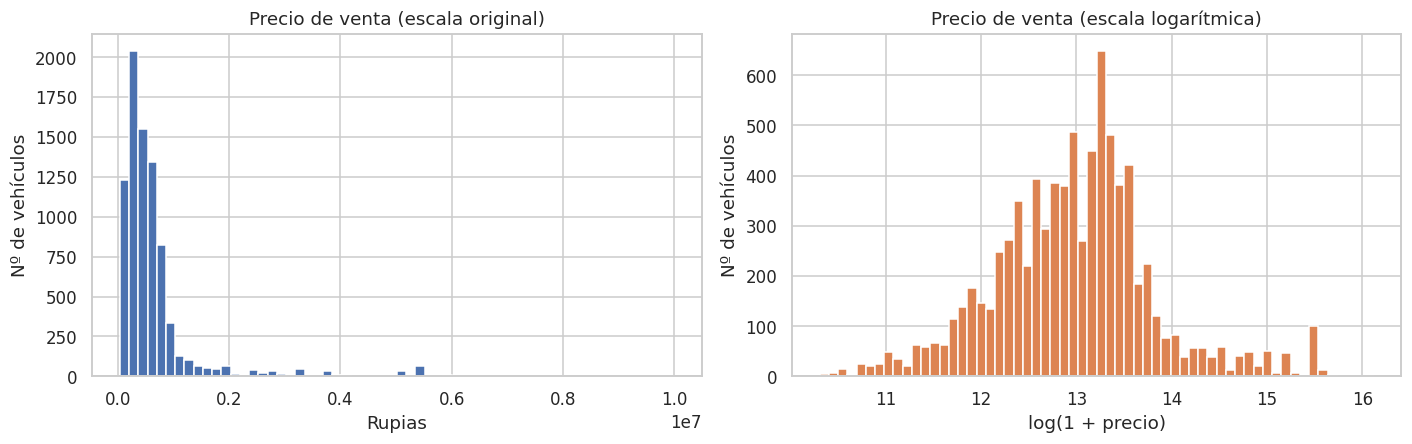

Asimetría en escala original : 4.19
Asimetría en escala log      : 0.22
Precio mínimo: 29,999   máximo: 10,000,000   mediana: 450,000


In [7]:
# ------------------------------------------------------------
# 1.6 Distribución del precio: el problema de la cola derecha
# ------------------------------------------------------------
fig, ax = plt.subplots(1, 2, figsize=(13, 4.2))

ax[0].hist(df_raw['selling_price'], bins=60, color='#4C72B0', edgecolor='white')
ax[0].set_title('Precio de venta (escala original)')
ax[0].set_xlabel('Rupias'); ax[0].set_ylabel('Nº de vehículos')

ax[1].hist(np.log1p(df_raw['selling_price']), bins=60, color='#DD8452', edgecolor='white')
ax[1].set_title('Precio de venta (escala logarítmica)')
ax[1].set_xlabel('log(1 + precio)'); ax[1].set_ylabel('Nº de vehículos')

plt.tight_layout(); plt.show()

print(f"Asimetría en escala original : {df_raw['selling_price'].skew():.2f}")
print(f"Asimetría en escala log      : {np.log1p(df_raw['selling_price']).skew():.2f}")
print(f"Precio mínimo: {df_raw['selling_price'].min():,.0f}   "
      f"máximo: {df_raw['selling_price'].max():,.0f}   "
      f"mediana: {df_raw['selling_price'].median():,.0f}")

La asimetría cae de un valor alto a prácticamente cero. Esto justifica una decisión que se
tomará en la Tarea 4: **entrenar los modelos de regresión sobre `log(1 + precio)`**.

La razón es concreta. La regresión lineal minimiza el error cuadrático, así que un carro de
10 millones de rupias con 20% de error aporta al costo lo mismo que cientos de carros baratos
bien predichos. El modelo termina optimizando para los vehículos de lujo, que son una minoría.
En escala logarítmica el error pasa a ser proporcional (equivocarse un 20% cuesta igual en un
carro barato que en uno caro), que es exactamente lo que le interesa a un negocio de compraventa.

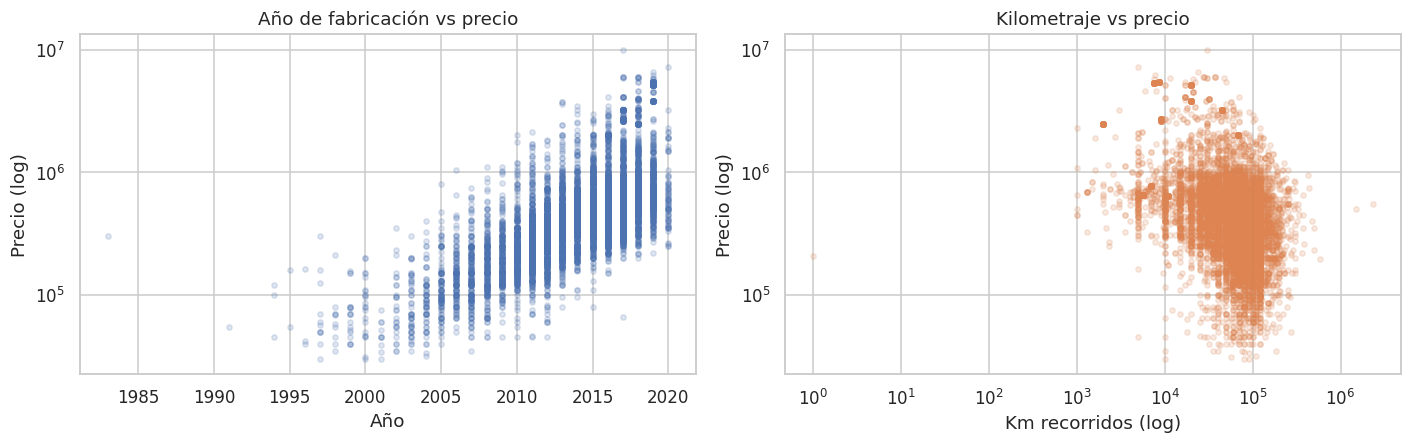

In [8]:
# ------------------------------------------------------------
# 1.7 Relación entre variables candidatas y precio
# ------------------------------------------------------------
fig, ax = plt.subplots(1, 2, figsize=(13, 4.2))

ax[0].scatter(df_raw['year'], df_raw['selling_price'], alpha=.18, s=12, color='#4C72B0')
ax[0].set_yscale('log'); ax[0].set_title('Año de fabricación vs precio')
ax[0].set_xlabel('Año'); ax[0].set_ylabel('Precio (log)')

ax[1].scatter(df_raw['km_driven'], df_raw['selling_price'], alpha=.18, s=12, color='#DD8452')
ax[1].set_xscale('log'); ax[1].set_yscale('log')
ax[1].set_title('Kilometraje vs precio')
ax[1].set_xlabel('Km recorridos (log)'); ax[1].set_ylabel('Precio (log)')

plt.tight_layout(); plt.show()

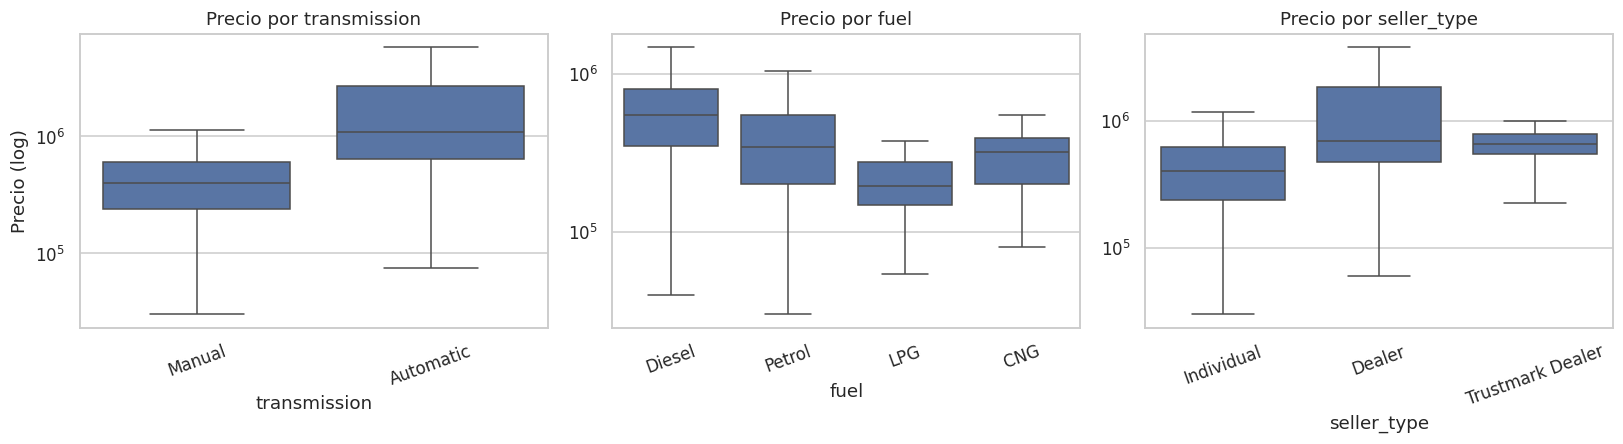

In [9]:
# ------------------------------------------------------------
# 1.8 Precio según variables categóricas
# ------------------------------------------------------------
fig, ax = plt.subplots(1, 3, figsize=(15, 4.2))

for i, col in enumerate(['transmission', 'fuel', 'seller_type']):
    sns.boxplot(data=df_raw, x=col, y='selling_price', ax=ax[i], showfliers=False)
    ax[i].set_yscale('log')
    ax[i].set_title(f'Precio por {col}')
    ax[i].set_ylabel('Precio (log)' if i == 0 else '')
    ax[i].tick_params(axis='x', rotation=20)

plt.tight_layout(); plt.show()

In [10]:
# ------------------------------------------------------------
# 1.9 Valores atípicos que no son plausibles en el mundo real
# ------------------------------------------------------------
print('Kilometrajes más altos registrados:')
print(df_raw['km_driven'].nlargest(6).to_string(index=False))

print(f"\nVehículos con más de 500.000 km: {(df_raw['km_driven'] > 500_000).sum()}")
print(f"Rango de años: {df_raw['year'].min()} – {df_raw['year'].max()}")
print(f"Registros con rendimiento declarado en 0.0 kmpl: {(df_raw['mileage'] == '0.0 kmpl').sum()}")

Kilometrajes más altos registrados:
2360457
1500000
 577414
 500000
 500000
 475000

Vehículos con más de 500.000 km: 3
Rango de años: 1983 – 2020
Registros con rendimiento declarado en 0.0 kmpl: 17


### Criterio para los atípicos

No todos los valores extremos son errores. Un carro de 7 millones de rupias es caro, pero
existe: se conserva. En cambio, **un vehículo particular con 2.360.457 km no es plausible**;
casi con seguridad es un error de digitación (un cero de más). Como son apenas dos registros,
se eliminan.

El criterio general que aplicamos: se eliminan los valores **físicamente imposibles**, no los
simplemente altos. Recortar los precios altos sería peor que inútil, porque el negocio de una
compraventa está justamente en tasar bien los vehículos caros.

Un rendimiento declarado de `0.0 kmpl` tampoco es posible, así que se trata como dato faltante
en lugar de como cero real.

---
## Reflexión de negocio (redactada **antes** de modelar)

Esta sección se escribió antes de entrenar cualquier modelo y no se editó después. En la Tarea 5
se contrasta contra lo que el modelo realmente encontró; el valor del ejercicio está en la
comparación honesta, acertemos o no.

**Hipótesis del equipo sobre qué determina el precio de un vehículo usado, en orden:**

1. **Antigüedad.** Un carro pierde valor de forma acelerada en sus primeros años. Esperamos que
   sea el factor individual más fuerte.
2. **Kilometraje.** Refleja el desgaste real. Esperamos que pese casi tanto como la antigüedad,
   aunque las dos están relacionadas entre sí.
3. **Potencia y cilindraje.** Separan gamas de mercado: un utilitario de 1.0 L y una camioneta
   de 2.5 L no compiten en el mismo segmento.
4. **Marca.** Hay marcas que sostienen su valor de reventa mejor que otras.
5. **Transmisión.** Las automáticas suelen estar en gamas más altas.
6. **Tipo de combustible.** Esperamos que el diésel se cotice algo por encima en vehículos
   grandes, pero con efecto menor que los anteriores.
7. **Número de propietarios previos.** Debería restar valor, aunque suponemos que su efecto es
   pequeño comparado con los años y el kilometraje.

**Predicción concreta y verificable:** esperamos que la antigüedad y el kilometraje aparezcan
en los dos primeros lugares de la importancia de variables del modelo de ensamble.

---
# Tarea 2 · Ingeniería de Características

Tres bloques de trabajo: recuperar las variables numéricas atrapadas en texto, aplicar la
limpieza decidida en la Tarea 1, y crear variables derivadas que el dataset no trae.

## 2.1 Extracción de las variables numéricas guardadas como texto

Antes de escribir el parser hay que mirar el contenido real de las columnas, porque tienen dos
trampas que no se ven en un `head()`.

In [11]:
# ------------------------------------------------------------
# Trampa 1: la columna 'mileage' mezcla dos unidades distintas
# ------------------------------------------------------------
unidad = df_raw['mileage'].astype(str).str.extract(r'(kmpl|km/kg)', expand=False)
print('Unidades encontradas en mileage:')
print(unidad.value_counts(dropna=False).to_string())

print('\nTipo de combustible de los registros medidos en km/kg:')
print(df_raw.loc[unidad == 'km/kg', 'fuel'].value_counts().to_string())

Unidades encontradas en mileage:
mileage
kmpl     7819
NaN       221
km/kg      88

Tipo de combustible de los registros medidos en km/kg:
fuel
CNG    53
LPG    35


`kmpl` (kilómetros por litro) y `km/kg` (kilómetros por kilogramo) **no son la misma magnitud**.
Los registros en `km/kg` corresponden exactamente a los vehículos de CNG y GLP, que se miden
por masa y no por volumen.

Extraer el número e ignorar la unidad mete 87 valores incomparables en la misma columna. Como
son menos del 1,5% del dataset y no existe un factor de conversión limpio (depende de la
densidad del gas), la decisión es **conservar el número y dejar registrada la limitación**, y
además mantener el tipo de combustible como variable para que el modelo pueda aislar esos casos.

In [12]:
# ------------------------------------------------------------
# Trampa 2: la columna 'torque' mezcla Nm y kgm, con formatos distintos
# ------------------------------------------------------------
print('Formatos presentes en la columna torque:')
for ejemplo in ['190Nm@ 2000rpm', '22.4 kgm at 1750-2750rpm', '12.7@ 2,700(kgm@ rpm)']:
    print('  ', ejemplo)

n_kgm = df_raw['torque'].astype(str).str.lower().str.contains('kgm').sum()
print(f'\nRegistros expresados en kgm: {n_kgm}  ({n_kgm/len(df_raw):.1%})')

Formatos presentes en la columna torque:
   190Nm@ 2000rpm
   22.4 kgm at 1750-2750rpm
   12.7@ 2,700(kgm@ rpm)

Registros expresados en kgm: 505  (6.2%)


In [13]:
# ------------------------------------------------------------
# Funciones de parseo
# ------------------------------------------------------------
def extraer_numero(texto):
    """Devuelve el primer número que aparece en una cadena ('1248 CC' -> 1248.0)."""
    if pd.isna(texto):
        return np.nan
    m = re.search(r'[-+]?\d*\.?\d+', str(texto))
    return float(m.group()) if m else np.nan


def extraer_torque_nm(texto):
    """Convierte el torque a Newton-metro, unificando los registros dados en kgm.

    1 kgm = 9.80665 Nm. Cuando el formato no declara la unidad de forma explícita
    ('12.7@ 2,700(kgm@ rpm)'), se usa la magnitud como criterio: los valores por debajo
    de 40 solo son plausibles en kgm, porque no existen motores de pasajeros con
    menos de 40 Nm de torque.
    """
    if pd.isna(texto):
        return np.nan
    t = str(texto).lower().replace(',', '')
    m = re.search(r'([\d.]+)\s*(nm|kgm)?', t)
    if not m:
        return np.nan
    valor, unidad = float(m.group(1)), m.group(2)
    if unidad is None:
        unidad = 'kgm' if valor < 40 else 'nm'
    return valor * 9.80665 if unidad == 'kgm' else valor


# Verificación del parser sobre casos representativos
casos = ['190Nm@ 2000rpm', '22.4 kgm at 1750-2750rpm', '12.7@ 2,700(kgm@ rpm)',
         '350Nm@ 1750-2500rpm', np.nan]
for c in casos:
    print(f'{str(c):<28} -> {extraer_torque_nm(c)}')

190Nm@ 2000rpm               -> 190.0
22.4 kgm at 1750-2750rpm     -> 219.66895999999997
12.7@ 2,700(kgm@ rpm)        -> 124.54445499999999
350Nm@ 1750-2500rpm          -> 350.0
nan                          -> nan


In [14]:
# ------------------------------------------------------------
# Aplicación del parseo
# ------------------------------------------------------------
df = df_raw.copy()

df['mileage_kmpl']  = df['mileage'].apply(extraer_numero).replace(0, np.nan)  # 0.0 kmpl = faltante
df['engine_cc']     = df['engine'].apply(extraer_numero)
df['max_power_bhp'] = df['max_power'].apply(extraer_numero)
df['torque_nm']     = df['torque'].apply(extraer_torque_nm)

print('Resultado del parseo:')
df[['mileage_kmpl','engine_cc','max_power_bhp','torque_nm']].describe().T

Resultado del parseo:


,count,mean,std,min,25%,50%,75%,max
mileage_kmpl,7890.0,19.460624,3.939457,9.0,16.78,19.33,22.32,42.0
engine_cc,7907.0,1458.625016,503.916303,624.0,1197.00,1248.00,1582.00,3604.0
max_power_bhp,7912.0,91.517919,35.822499,0.0,68.05,82.00,102.00,400.0
torque_nm,7906.0,177.044204,90.523637,42.0,111.80,170.00,205.00,789.0


## 2.2 Limpieza, aplicando los criterios documentados en la Tarea 1

Cada paso deja registro de cuántas filas elimina, para que la trazabilidad sea verificable.

In [15]:
# ------------------------------------------------------------
# Limpieza con bitácora
# ------------------------------------------------------------
bitacora = []
def registrar(paso, df_actual, antes):
    bitacora.append({'paso': paso, 'filas_eliminadas': antes - len(df_actual),
                     'filas_restantes': len(df_actual)})

n = len(df); bitacora.append({'paso':'Dataset original','filas_eliminadas':0,'filas_restantes':n})

n0 = len(df); df = df.drop_duplicates().reset_index(drop=True)
registrar('Eliminar duplicados exactos', df, n0)

n0 = len(df); df = df[df['owner'] != 'Test Drive Car']
registrar("Excluir 'Test Drive Car'", df, n0)

n0 = len(df); df = df[df['km_driven'] <= 500_000]
registrar('Eliminar kilometrajes imposibles (>500.000 km)', df, n0)

n0 = len(df)
df = df.dropna(subset=['mileage_kmpl','engine_cc','max_power_bhp','torque_nm','seats'])
registrar('Eliminar filas sin ficha técnica', df, n0)

df = df.reset_index(drop=True)
pd.DataFrame(bitacora)

,paso,filas_eliminadas,filas_restantes
0,Dataset original,0,8128
1,Eliminar duplicados exactos,1202,6926
2,Excluir 'Test Drive Car',5,6921
3,Eliminar kilometrajes imposibles (>500.000 km),3,6918
4,Eliminar filas sin ficha técnica,224,6694


## 2.3 Creación de variables derivadas

El enunciado pide al menos dos variables nuevas. Creamos cuatro, cada una con una razón de
negocio detrás y no solo por combinar columnas.

In [16]:
# ------------------------------------------------------------
# Variables derivadas
# ------------------------------------------------------------

# (1) Antigüedad: más interpretable que el año absoluto. Un modelo entrenado sobre 'year'
#     aprende años concretos; entrenado sobre 'antigüedad' aprende una relación de desgaste
#     que sigue teniendo sentido cuando el dataset envejece.
df['antiguedad'] = ANIO_REFERENCIA - df['year']

# (2) Kilómetros por año: distingue dos carros de 2015 con 100.000 km y con 20.000 km.
#     Es la variable que un comprador realmente mira ("poco recorrido para su año").
df['km_por_anio'] = df['km_driven'] / df['antiguedad'].clip(lower=1)

# (3) Potencia específica (bhp por litro): separa un motor 1.2 aspirado de un 1.2 turbo,
#     que pertenecen a segmentos de precio distintos aunque tengan igual cilindraje.
df['potencia_por_litro'] = df['max_power_bhp'] / (df['engine_cc'] / 1000)

# (4) Marca extraída del nombre comercial. El nombre completo tiene demasiadas variantes
#     ('Maruti Swift Dzire VDI') para usarse como categoría; la marca sí es manejable.
df['marca'] = df['name'].str.split().str[0]

# Codificación ordinal de 'owner' (respeta el orden natural de la variable)
mapa_owner = {'First Owner': 1, 'Second Owner': 2, 'Third Owner': 3, 'Fourth & Above Owner': 4}
df['owner_ord'] = df['owner'].map(mapa_owner)

print(f'Marcas distintas: {df["marca"].nunique()}')
print(df['marca'].value_counts().head(10).to_string())
df[['antiguedad','km_por_anio','potencia_por_litro','owner_ord']].describe().T

Marcas distintas: 31
marca
Maruti        2088
Hyundai       1206
Mahindra       706
Tata           632
Honda          360
Ford           353
Toyota         324
Chevrolet      216
Renault        206
Volkswagen     170


,count,mean,std,min,25%,50%,75%,max
antiguedad,6694.0,6.388408,3.895814,0.000000,3.000000,6.000000,9.000000,26.000000
km_por_anio,6694.0,13362.712892,9357.774021,0.111111,7500.000000,11250.000000,16666.666667,120000.000000
potencia_por_litro,6694.0,62.526184,12.253618,21.312585,58.820573,64.249656,68.387636,203.148807
owner_ord,6694.0,1.497311,0.731508,1.000000,1.000000,1.000000,2.000000,4.000000


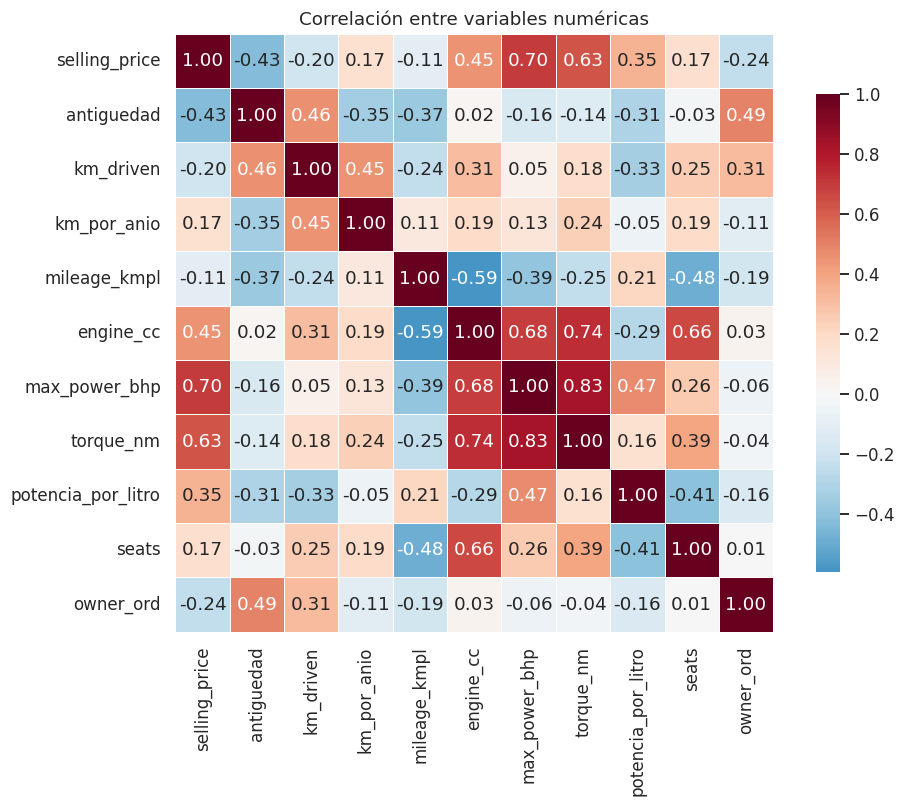

Pares de variables con correlación absoluta mayor a 0.7:
  engine_cc            ~ torque_nm            r = +0.74
  max_power_bhp        ~ torque_nm            r = +0.83


In [17]:
# ------------------------------------------------------------
# 2.4 Matriz de correlación: dónde está la multicolinealidad
# ------------------------------------------------------------
num_corr = ['selling_price','antiguedad','km_driven','km_por_anio','mileage_kmpl',
            'engine_cc','max_power_bhp','torque_nm','potencia_por_litro','seats','owner_ord']

corr = df[num_corr].corr()

plt.figure(figsize=(9.5, 7.5))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='RdBu_r', center=0,
            square=True, linewidths=.5, cbar_kws={'shrink': .8})
plt.title('Correlación entre variables numéricas')
plt.tight_layout(); plt.show()

print('Pares de variables con correlación absoluta mayor a 0.7:')
for i in range(len(num_corr)):
    for j in range(i+1, len(num_corr)):
        c = corr.iloc[i, j]
        if abs(c) > 0.7:
            print(f'  {num_corr[i]:<20} ~ {num_corr[j]:<20} r = {c:+.2f}')

### Por qué esta matriz importa para la Tarea 4

`engine_cc`, `max_power_bhp` y `torque_nm` están fuertemente correlacionadas entre sí: describen
lo mismo (el tamaño del motor) desde tres ángulos. Eso es **multicolinealidad**, y es
exactamente el problema que ataca la regresión Ridge. Cuando varias variables aportan
información redundante, los coeficientes de una regresión lineal ordinaria se vuelven
inestables: pequeños cambios en los datos producen coeficientes muy distintos, a veces con
signo invertido, y el modelo deja de ser interpretable aunque prediga bien.

No eliminamos esas variables a mano: dejamos que Ridge y Lasso muestren su efecto, que es lo
que pide el enunciado.

## 2.5 Escalamiento: qué modelos lo necesitan y cuáles no

El enunciado pide escalar "cuando el modelo elegido lo requiera", justificando la técnica. La
respuesta no es la misma para todos los modelos de este proyecto:

| Familia de modelo | ¿Requiere escalamiento? | Razón |
|---|---|---|
| Regresión lineal, Ridge, Lasso | **Sí** | La penalización de Ridge y Lasso castiga el tamaño de los coeficientes. Sin escalar, una variable en decenas de miles (km) recibe un coeficiente diminuto y otra en unidades (nº de asientos) uno grande, y la penalización termina castigando la unidad de medida en lugar de la irrelevancia. |
| Regresión logística | **Sí** | Mismo motivo, más la convergencia del optimizador. |
| k-Nearest Neighbors | **Sí, críticamente** | Se basa en distancias. Sin escalar, el kilometraje domina la distancia euclidiana y las demás variables dejan de existir. |
| Árbol de decisión, Random Forest, Gradient Boosting | **No** | Parten por umbrales sobre cada variable por separado (`km_driven <= 45.000`). Una transformación monótona no cambia ningún corte. |

**Técnica elegida: `StandardScaler`** (media 0, desviación 1) en lugar de `MinMaxScaler`. El
motivo es que `MinMaxScaler` comprime el rango según el mínimo y el máximo, y este dataset tiene
valores extremos legítimos en precio y kilometraje: un solo carro con 500.000 km aplastaría al
resto de la distribución contra el cero. `StandardScaler` usa media y desviación, que son mucho
menos sensibles a un extremo aislado.

Se definen entonces **dos preprocesadores**: uno con escalamiento para los modelos lineales y de
distancia, y otro sin escalamiento para los basados en árboles.

In [18]:
# ------------------------------------------------------------
# Definición de las variables predictoras y de los preprocesadores
# ------------------------------------------------------------
VARS_NUM = ['antiguedad','km_driven','km_por_anio','mileage_kmpl','engine_cc',
            'max_power_bhp','torque_nm','potencia_por_litro','seats','owner_ord']
VARS_CAT = ['fuel','seller_type','transmission','marca']

X = df[VARS_NUM + VARS_CAT].copy()
y = df['selling_price'].copy()

# Preprocesador CON escalamiento -> modelos lineales y KNN
prep_escalado = ColumnTransformer([
    ('num', StandardScaler(), VARS_NUM),
    ('cat', OneHotEncoder(handle_unknown='ignore', drop='first'), VARS_CAT)
])

# Preprocesador SIN escalamiento -> árboles y ensambles
prep_arboles = ColumnTransformer([
    ('num', 'passthrough', VARS_NUM),
    ('cat', OneHotEncoder(handle_unknown='ignore', drop='first'), VARS_CAT)
])

print(f'Variables numéricas   : {len(VARS_NUM)}')
print(f'Variables categóricas : {len(VARS_CAT)}')
print(f'Dataset final         : {X.shape[0]} filas')

Variables numéricas   : 10
Variables categóricas : 4
Dataset final         : 6694 filas


### `handle_unknown='ignore'` y `drop='first'`

Dos parámetros que vale la pena poder explicar en la sustentación:

- **`handle_unknown='ignore'`**: hay marcas con muy pocos registros (Lexus, Opel, Peugeot tienen
  1 cada una). Es perfectamente posible que una de ellas caiga solo en el conjunto de prueba. Sin
  este parámetro el modelo lanzaría un error al encontrar una categoría que nunca vio; con él,
  la codifica como todo ceros y sigue.
- **`drop='first'`**: elimina una categoría de referencia por variable para evitar colinealidad
  perfecta entre las columnas dummy (la llamada trampa de la variable ficticia), que afecta
  específicamente a los modelos lineales.

---
# Partición de los datos

Este paso va **antes** de la Tarea 3 a propósito. Todo lo que venga después (cortes de las
categorías de precio, ajuste del escalador, búsqueda de hiperparámetros) se calcula únicamente
sobre `X_train`. El conjunto de prueba se toca una sola vez, al final, para reportar.

In [19]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=RANDOM_STATE)

# Versión logarítmica del objetivo, para los modelos de regresión
y_train_log = np.log1p(y_train)
y_test_log  = np.log1p(y_test)

print(f'Entrenamiento: {X_train.shape[0]} vehículos')
print(f'Prueba       : {X_test.shape[0]} vehículos')
print(f'\nPrecio mediano en train: {y_train.median():,.0f} rupias')
print(f'Precio mediano en test : {y_test.median():,.0f} rupias')

Entrenamiento: 5355 vehículos
Prueba       : 1339 vehículos

Precio mediano en train: 411,000 rupias
Precio mediano en test : 434,999 rupias


---
# Tarea 3 · Clasificación en Rangos de Precio

## 3.1 Criterio para definir las categorías

Se evaluaron dos alternativas:

- **Cortes de negocio fijos** (por ejemplo, "menos de 300.000 = económico"). Son intuitivos para
  el área comercial, pero producen clases muy desbalanceadas y quedan obsoletos con la inflación.
- **Terciles de la distribución** (33% más barato, 33% intermedio, 33% más caro). Genera tres
  clases de tamaño similar, lo cual evita que un modelo consiga buena exactitud simplemente
  prediciendo siempre la clase mayoritaria.

**Elegimos terciles**, y añadimos un detalle metodológico que sí cambia la validez del ejercicio:
los cortes se calculan **solo sobre el conjunto de entrenamiento**. Si se calcularan sobre el
dataset completo, la definición misma de "caro" incorporaría información de los vehículos de
prueba.

In [20]:
# ------------------------------------------------------------
# Definición de las categorías de precio a partir del train
# ------------------------------------------------------------
corte_bajo, corte_alto = y_train.quantile([1/3, 2/3]).values
print(f'Cortes calculados sobre el conjunto de entrenamiento:')
print(f'  Bajo  : hasta {corte_bajo:,.0f} rupias')
print(f'  Medio : entre {corte_bajo:,.0f} y {corte_alto:,.0f} rupias')
print(f'  Alto  : más de {corte_alto:,.0f} rupias')

def categorizar_precio(valores):
    return np.where(valores <= corte_bajo, 'Bajo',
           np.where(valores <= corte_alto, 'Medio', 'Alto'))

c_train = categorizar_precio(y_train)
c_test  = categorizar_precio(y_test)

print('\nDistribución de clases:')
print(pd.DataFrame({
    'train': pd.Series(c_train).value_counts(),
    'test' : pd.Series(c_test).value_counts()
}).loc[['Bajo','Medio','Alto']])

Cortes calculados sobre el conjunto de entrenamiento:
  Bajo  : hasta 300,000 rupias
  Medio : entre 300,000 y 550,000 rupias
  Alto  : más de 550,000 rupias

Distribución de clases:
       train  test
Bajo    1861   425
Medio   1716   460
Alto    1778   454


**Advertencia sobre fuga de información:** la categoría se deriva del precio, así que el precio
(y cualquier variable calculada a partir de él) **no puede estar entre las predictoras**. En este
notebook `X` nunca contuvo `selling_price`; es el tipo de error que arruina un proyecto entero
y conviene mencionarlo explícitamente en la sustentación.

## 3.2 Entrenamiento de tres clasificadores

El enunciado pide al menos dos. Usamos tres, de familias distintas a propósito, para que la
comparación diga algo:

- **Regresión logística**: modelo lineal, alta interpretabilidad, sirve como línea base.
- **k-Nearest Neighbors**: no asume ninguna forma funcional, se basa solo en similitud.
- **Árbol de decisión**: capta interacciones y umbrales, y es el que un área comercial entiende
  sin saber estadística.

In [21]:
# ------------------------------------------------------------
# Entrenamiento y evaluación
# ------------------------------------------------------------
clasificadores = {
    'Regresión logística': Pipeline([('prep', prep_escalado),
                                     ('modelo', LogisticRegression(max_iter=2000,
                                                                   random_state=RANDOM_STATE))]),
    'KNN (k=5)':           Pipeline([('prep', prep_escalado),
                                     ('modelo', KNeighborsClassifier(n_neighbors=5))]),
    'Árbol de decisión':   Pipeline([('prep', prep_arboles),
                                     ('modelo', DecisionTreeClassifier(random_state=RANDOM_STATE))]),
}

resultados_clf = []
predicciones_clf = {}

for nombre, pipe in clasificadores.items():
    pipe.fit(X_train, c_train)
    pred = pipe.predict(X_test)
    predicciones_clf[nombre] = pred
    resultados_clf.append({
        'modelo'   : nombre,
        'accuracy' : accuracy_score(c_test, pred),
        'precision': precision_score(c_test, pred, average='macro'),
        'recall'   : recall_score(c_test, pred, average='macro'),
        'f1_macro' : f1_score(c_test, pred, average='macro'),
    })

tabla_clf = pd.DataFrame(resultados_clf).sort_values('f1_macro', ascending=False)
tabla_clf.style.format({'accuracy':'{:.3f}','precision':'{:.3f}',
                        'recall':'{:.3f}','f1_macro':'{:.3f}'}).hide(axis='index')

modelo,accuracy,precision,recall,f1_macro
Regresión logística,0.811,0.813,0.812,0.813
Árbol de decisión,0.799,0.799,0.801,0.800
KNN (k=5),0.795,0.798,0.796,0.797


**Por qué se reporta el F1 macro y no solo la exactitud.** El promedio macro calcula la métrica
para cada clase por separado y luego promedia sin ponderar por tamaño. Con clases balanceadas
como estas los dos valores se parecen, pero el macro es el que revela si un modelo está fallando
sistemáticamente en una clase concreta. Y ese es justo el caso: como se ve enseguida, la clase
"Medio" es la difícil.

In [22]:
# ------------------------------------------------------------
# Reporte detallado por clase y matrices de confusión
# ------------------------------------------------------------
etiquetas = ['Bajo','Medio','Alto']

for nombre, pred in predicciones_clf.items():
    print(f'===== {nombre} =====')
    print(classification_report(c_test, pred, labels=etiquetas, digits=3))

===== Regresión logística =====
              precision    recall  f1-score   support

        Bajo      0.877     0.852     0.864       425
       Medio      0.724     0.730     0.727       460
        Alto      0.840     0.855     0.847       454

    accuracy                          0.811      1339
   macro avg      0.813     0.812     0.813      1339
weighted avg      0.812     0.811     0.811      1339

===== KNN (k=5) =====
              precision    recall  f1-score   support

        Bajo      0.877     0.842     0.860       425
       Medio      0.708     0.711     0.709       460
        Alto      0.808     0.835     0.821       454

    accuracy                          0.795      1339
   macro avg      0.798     0.796     0.797      1339
weighted avg      0.796     0.795     0.795      1339

===== Árbol de decisión =====
              precision    recall  f1-score   support

        Bajo      0.830     0.859     0.844       425
       Medio      0.717     0.696     0.706  

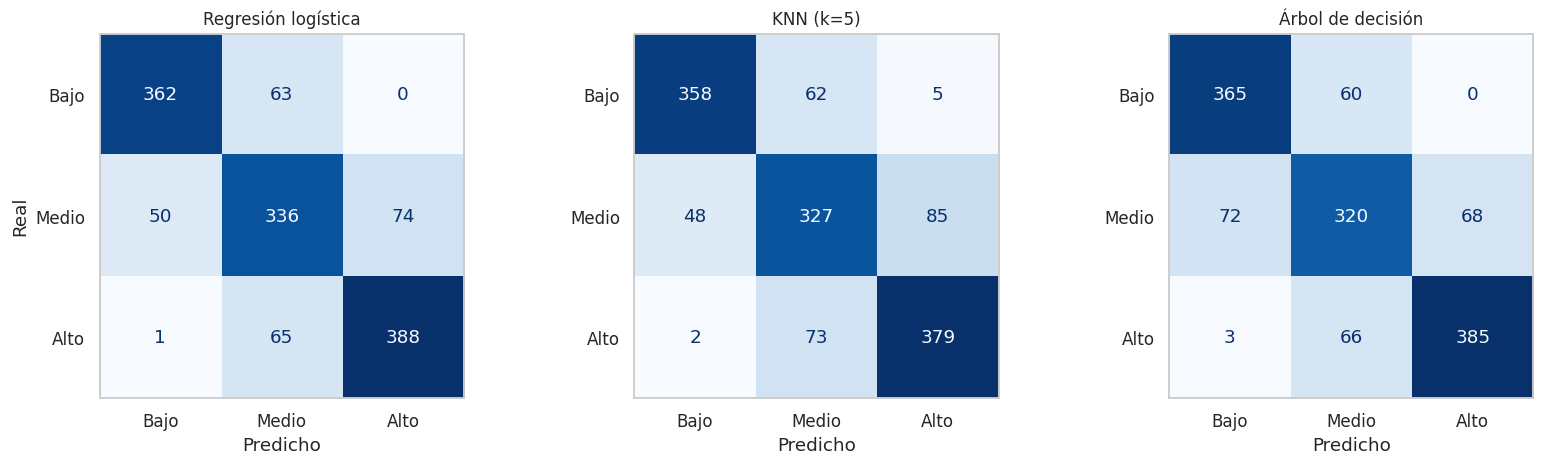

In [23]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4.4))

for ax, (nombre, pred) in zip(axes, predicciones_clf.items()):
    cm = confusion_matrix(c_test, pred, labels=etiquetas)
    ConfusionMatrixDisplay(cm, display_labels=etiquetas).plot(
        ax=ax, cmap='Blues', colorbar=False, values_format='d')
    ax.set_title(nombre, fontsize=11)
    ax.set_xlabel('Predicho'); ax.set_ylabel('Real' if ax is axes[0] else '')
    ax.grid(False)

plt.tight_layout(); plt.show()

### Lectura de las matrices de confusión

El patrón se repite en los tres modelos: **los errores se concentran en la frontera entre clases
contiguas**. Los vehículos "Medio" se confunden con "Bajo" o con "Alto", pero casi nunca un
"Bajo" se clasifica como "Alto".

Esto es una buena noticia de negocio, no un defecto. Significa que el modelo no comete errores
absurdos: se equivoca en carros que están justo sobre la línea de corte, donde incluso un tasador
humano dudaría. Un carro de 305.000 rupias clasificado como "Bajo" cuando el corte está en
300.000 es un error contable, no un error de criterio.

---
# Tarea 4 · Regresión

## 4.1 Regresión lineal y el efecto de la transformación logarítmica

Se entrena primero la regresión lineal de dos formas —sobre el precio directo y sobre su
logaritmo— para mostrar con números la decisión anticipada en la Tarea 1. En ambos casos las
métricas se calculan sobre el **precio en rupias**, no en escala logarítmica: un RMSE en unidades
logarítmicas no es interpretable ni comparable.

In [24]:
# ------------------------------------------------------------
# Función de evaluación reutilizable
# ------------------------------------------------------------
def evaluar_regresion(nombre, pipeline, usar_log=True, guardar_pred=False):
    """Entrena y evalúa un pipeline de regresión, siempre reportando en rupias."""
    objetivo = y_train_log if usar_log else y_train
    pipeline.fit(X_train, objetivo)
    pred = pipeline.predict(X_test)
    if usar_log:
        pred = np.expm1(pred)          # se devuelve a rupias antes de medir
    mse  = mean_squared_error(y_test, pred)
    fila = {'modelo': nombre, 'MSE': mse, 'RMSE': np.sqrt(mse),
            'R2': r2_score(y_test, pred)}
    return (fila, pred) if guardar_pred else fila


resultados_reg = []
resultados_reg.append(evaluar_regresion(
    'Lineal (precio directo)',
    Pipeline([('prep', prep_escalado), ('modelo', LinearRegression())]), usar_log=False))
resultados_reg.append(evaluar_regresion(
    'Lineal (log del precio)',
    Pipeline([('prep', prep_escalado), ('modelo', LinearRegression())]), usar_log=True))

pd.DataFrame(resultados_reg).style.format(
    {'MSE':'{:,.0f}','RMSE':'{:,.0f}','R2':'{:.4f}'}).hide(axis='index')

modelo,MSE,RMSE,R2
Lineal (precio directo),"73,013,175,187","270,210",0.6863
Lineal (log del precio),"21,773,115,287","147,557",0.9065


El salto en R² viene de una sola línea de código. Es el mejor argumento del proyecto sobre por
qué el preprocesamiento importa más que la elección del algoritmo: el mismo modelo lineal, con
los mismos datos, pasa de mediocre a competitivo solo por modelar la variable en la escala
correcta. De aquí en adelante todos los modelos de regresión usan la escala logarítmica.

## 4.2 Ridge y Lasso: qué problema resuelve cada una

Ambas añaden una penalización sobre el tamaño de los coeficientes, pero atacan problemas
distintos:

**Ridge (penalización L2)** castiga la suma de los coeficientes **al cuadrado**. Los reduce hacia
cero de forma suave, sin anularlos. Su función aquí es la **multicolinealidad**: cuando
`engine_cc`, `max_power_bhp` y `torque_nm` dicen casi lo mismo, la regresión ordinaria reparte el
peso entre ellas de forma inestable; Ridge reparte el peso de manera equilibrada y los
coeficientes dejan de dispararse.

**Lasso (penalización L1)** castiga la suma de los **valores absolutos**. Esta diferencia
matemática tiene una consecuencia práctica grande: Lasso puede llevar coeficientes exactamente a
cero, o sea que hace **selección automática de variables**. Su función aquí es el **sobreajuste
por exceso de variables**: con las dummies de 32 marcas más las numéricas, el modelo tiene muchas
más columnas que información real, y Lasso apaga las que no aportan.

En lugar de quedarnos en la definición, mostramos la evidencia de cada una.

In [25]:
resultados_reg.append(evaluar_regresion(
    'Ridge (alpha=1.0)',
    Pipeline([('prep', prep_escalado), ('modelo', Ridge(alpha=1.0, random_state=RANDOM_STATE))])))
resultados_reg.append(evaluar_regresion(
    'Lasso (alpha=0.001)',
    Pipeline([('prep', prep_escalado), ('modelo', Lasso(alpha=0.001, random_state=RANDOM_STATE))])))

pd.DataFrame(resultados_reg).style.format(
    {'MSE':'{:,.0f}','RMSE':'{:,.0f}','R2':'{:.4f}'}).hide(axis='index')

modelo,MSE,RMSE,R2
Lineal (precio directo),"73,013,175,187","270,210",0.6863
Lineal (log del precio),"21,773,115,287","147,557",0.9065
Ridge (alpha=1.0),"21,423,429,277","146,367",0.9080
Lasso (alpha=0.001),"21,584,431,922","146,916",0.9073


In [26]:
# ------------------------------------------------------------
# Evidencia 1: Lasso apaga variables, Ridge solo las encoge
# ------------------------------------------------------------
pipe_ridge = Pipeline([('prep', prep_escalado), ('modelo', Ridge(alpha=1.0))]).fit(X_train, y_train_log)
pipe_lasso = Pipeline([('prep', prep_escalado), ('modelo', Lasso(alpha=0.01))]).fit(X_train, y_train_log)

nombres_vars = pipe_ridge.named_steps['prep'].get_feature_names_out()
coefs = pd.DataFrame({
    'variable': [n.split('__')[-1] for n in nombres_vars],
    'Ridge': pipe_ridge.named_steps['modelo'].coef_,
    'Lasso': pipe_lasso.named_steps['modelo'].coef_,
})

print(f'Coeficientes exactamente en cero -> Ridge: {(coefs["Ridge"] == 0).sum()}'
      f'   Lasso: {(coefs["Lasso"] == 0).sum()}  (de {len(coefs)} variables)')
print('\nVariables que Lasso descartó por completo:')
print(', '.join(coefs.loc[coefs['Lasso'] == 0, 'variable'].tolist()[:20]))

Coeficientes exactamente en cero -> Ridge: 0   Lasso: 34  (de 46 variables)

Variables que Lasso descartó por completo:
km_por_anio, mileage_kmpl, seats, fuel_LPG, fuel_Petrol, seller_type_Individual, seller_type_Trustmark Dealer, transmission_Manual, marca_Ashok, marca_Audi, marca_BMW, marca_Daewoo, marca_Datsun, marca_Fiat, marca_Force, marca_Ford, marca_Honda, marca_Hyundai, marca_Isuzu, marca_Jaguar


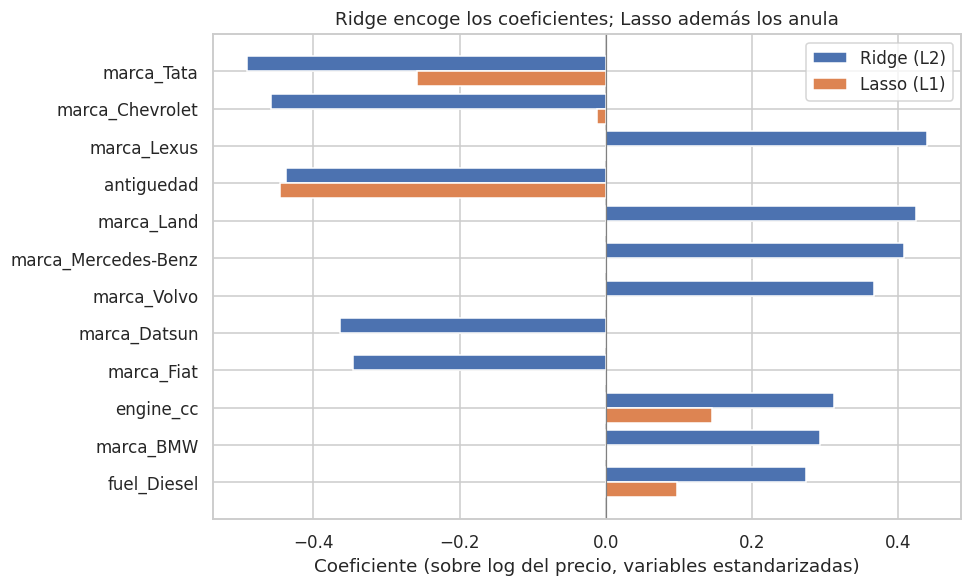

In [27]:
# Las 12 variables más influyentes según Ridge, comparadas con Lasso
top = coefs.reindex(coefs['Ridge'].abs().sort_values(ascending=False).index).head(12)

fig, ax = plt.subplots(figsize=(9, 5.5))
pos = np.arange(len(top))
ax.barh(pos - 0.2, top['Ridge'], height=0.4, label='Ridge (L2)', color='#4C72B0')
ax.barh(pos + 0.2, top['Lasso'], height=0.4, label='Lasso (L1)', color='#DD8452')
ax.set_yticks(pos); ax.set_yticklabels(top['variable'])
ax.invert_yaxis(); ax.axvline(0, color='grey', lw=.8)
ax.set_xlabel('Coeficiente (sobre log del precio, variables estandarizadas)')
ax.set_title('Ridge encoge los coeficientes; Lasso además los anula')
ax.legend()
plt.tight_layout(); plt.show()

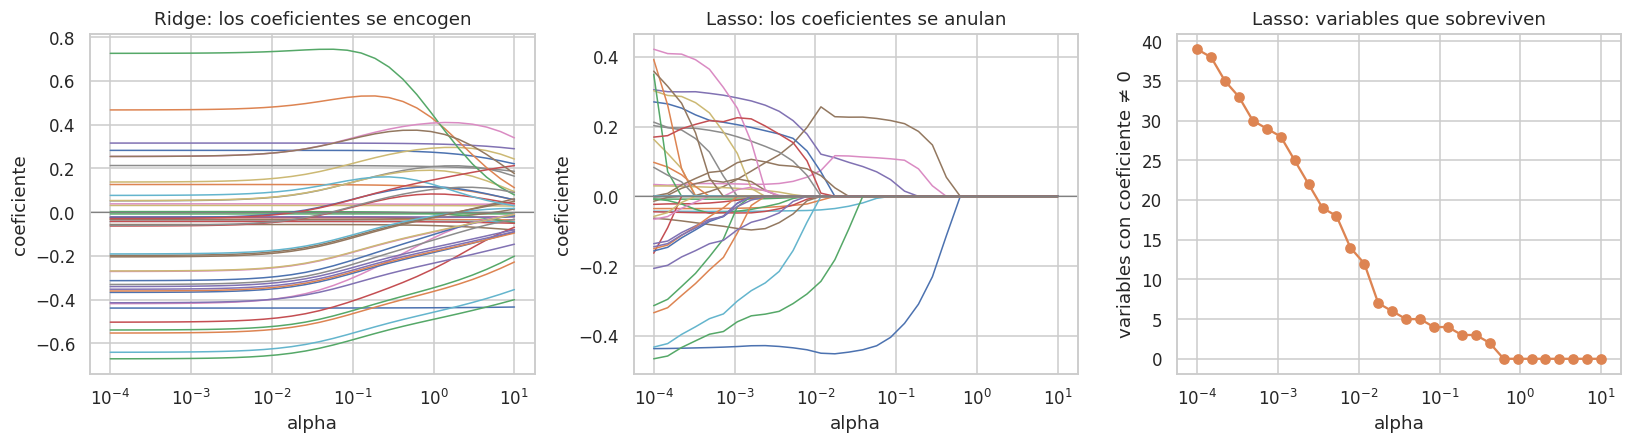

In [28]:
# ------------------------------------------------------------
# Evidencia 2: camino de regularización
# ------------------------------------------------------------
alphas = np.logspace(-4, 1, 30)
camino_ridge, camino_lasso, n_vivas = [], [], []

Xtr_proc = prep_escalado.fit_transform(X_train)

for a in alphas:
    camino_ridge.append(Ridge(alpha=a).fit(Xtr_proc, y_train_log).coef_)
    cl = Lasso(alpha=a, max_iter=5000).fit(Xtr_proc, y_train_log).coef_
    camino_lasso.append(cl)
    n_vivas.append((cl != 0).sum())

camino_ridge, camino_lasso = np.array(camino_ridge), np.array(camino_lasso)

fig, ax = plt.subplots(1, 3, figsize=(15, 4.2))
for k in range(camino_ridge.shape[1]):
    ax[0].plot(alphas, camino_ridge[:, k], lw=1)
    ax[1].plot(alphas, camino_lasso[:, k], lw=1)
ax[0].set_xscale('log'); ax[0].set_title('Ridge: los coeficientes se encogen')
ax[1].set_xscale('log'); ax[1].set_title('Lasso: los coeficientes se anulan')
for a_ in ax[:2]:
    a_.set_xlabel('alpha'); a_.set_ylabel('coeficiente'); a_.axhline(0, color='grey', lw=.8)

ax[2].plot(alphas, n_vivas, marker='o', color='#DD8452')
ax[2].set_xscale('log'); ax[2].set_xlabel('alpha')
ax[2].set_ylabel('variables con coeficiente ≠ 0')
ax[2].set_title('Lasso: variables que sobreviven')

plt.tight_layout(); plt.show()

El panel de la derecha es la demostración visual de la selección de variables: a medida que crece
la penalización, Lasso va apagando predictoras hasta quedarse con un puñado. Ridge, en el panel
izquierdo, nunca llega a cero por más que se aumente alpha.

Los valores de alpha usados aquí son arbitrarios a propósito. **En la Tarea 6 se busca el alpha
óptimo con validación cruzada**, que es la forma correcta de elegirlo.

---
# Tarea 5 · Árboles de Decisión y Modelos de Ensamble

## 5.1 Árbol de decisión para regresión

Un árbol funciona de manera radicalmente distinta a los modelos anteriores: en lugar de una
fórmula, aprende una secuencia de preguntas de sí/no. Eso lo hace el modelo más fácil de explicar
a alguien sin formación técnica, que es justo lo que pide la Tarea 7.

Se entrena primero **sin límite de profundidad** para mostrar el sobreajuste, y luego uno podado.

In [29]:
# ------------------------------------------------------------
# Árbol sin podar vs árbol podado
# ------------------------------------------------------------
arbol_libre = Pipeline([('prep', prep_arboles),
                        ('modelo', DecisionTreeRegressor(random_state=RANDOM_STATE))])
arbol_libre.fit(X_train, y_train_log)

pred_train = np.expm1(arbol_libre.predict(X_train))
pred_test  = np.expm1(arbol_libre.predict(X_test))

print('Árbol sin límite de profundidad')
print(f'  Profundidad alcanzada : {arbol_libre.named_steps["modelo"].get_depth()}')
print(f'  Hojas                 : {arbol_libre.named_steps["modelo"].get_n_leaves()}')
print(f'  R² en ENTRENAMIENTO   : {r2_score(y_train, pred_train):.4f}')
print(f'  R² en PRUEBA          : {r2_score(y_test,  pred_test):.4f}')
print('\n  La diferencia entre ambos R² es la definición operativa de sobreajuste:')
print('  el árbol memorizó el conjunto de entrenamiento casi a la perfección.')

Árbol sin límite de profundidad
  Profundidad alcanzada : 32
  Hojas                 : 4825
  R² en ENTRENAMIENTO   : 0.9992
  R² en PRUEBA          : 0.8669

  La diferencia entre ambos R² es la definición operativa de sobreajuste:
  el árbol memorizó el conjunto de entrenamiento casi a la perfección.


In [30]:
resultados_reg.append(evaluar_regresion(
    'Árbol de decisión (sin podar)',
    Pipeline([('prep', prep_arboles),
              ('modelo', DecisionTreeRegressor(random_state=RANDOM_STATE))])))

resultados_reg.append(evaluar_regresion(
    'Árbol de decisión (max_depth=8)',
    Pipeline([('prep', prep_arboles),
              ('modelo', DecisionTreeRegressor(max_depth=8, min_samples_leaf=5,
                                               random_state=RANDOM_STATE))])))

pd.DataFrame(resultados_reg).style.format(
    {'MSE':'{:,.0f}','RMSE':'{:,.0f}','R2':'{:.4f}'}).hide(axis='index')

modelo,MSE,RMSE,R2
Lineal (precio directo),"73,013,175,187","270,210",0.6863
Lineal (log del precio),"21,773,115,287","147,557",0.9065
Ridge (alpha=1.0),"21,423,429,277","146,367",0.9080
Lasso (alpha=0.001),"21,584,431,922","146,916",0.9073
Árbol de decisión (sin podar),"30,979,878,260","176,011",0.8669
Árbol de decisión (max_depth=8),"26,181,847,666","161,808",0.8875


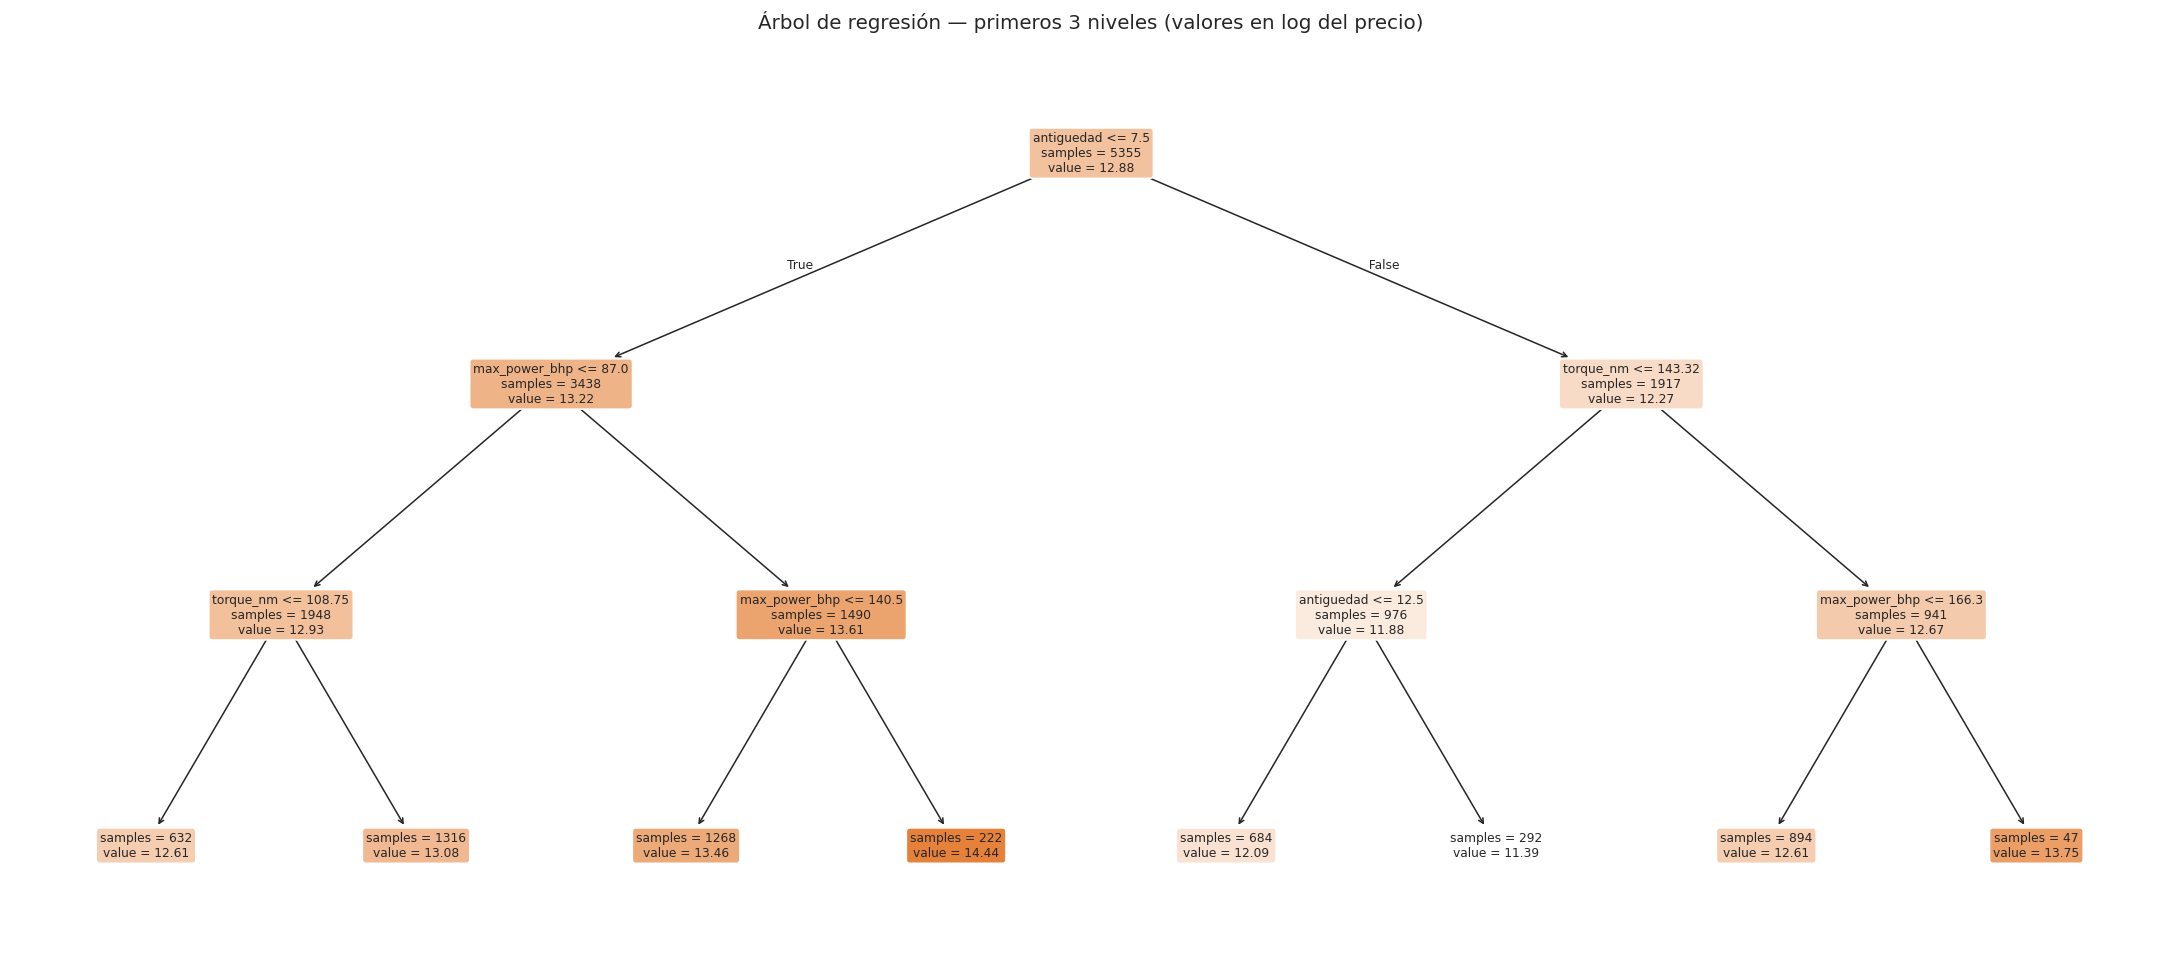

In [31]:
# ------------------------------------------------------------
# 5.2 Visualización del árbol (primeros 3 niveles)
# ------------------------------------------------------------
arbol_viz = Pipeline([('prep', prep_arboles),
                      ('modelo', DecisionTreeRegressor(max_depth=3, random_state=RANDOM_STATE))])
arbol_viz.fit(X_train, y_train_log)

nombres = [n.split('__')[-1] for n in arbol_viz.named_steps['prep'].get_feature_names_out()]

plt.figure(figsize=(20, 9))
plot_tree(arbol_viz.named_steps['modelo'], feature_names=nombres, filled=True,
          rounded=True, fontsize=8, precision=2, impurity=False)
plt.title('Árbol de regresión — primeros 3 niveles (valores en log del precio)', fontsize=13)
plt.tight_layout(); plt.show()

In [32]:
# Traducción de la raíz del árbol a lenguaje de negocio
t = arbol_viz.named_steps['modelo'].tree_
raiz_var   = nombres[t.feature[0]]
raiz_corte = t.threshold[0]

# children_left / children_right dan los índices reales de los hijos.
# No son 1 y 2: el hijo derecho viene después de todo el subárbol izquierdo.
izq = np.expm1(t.value[t.children_left[0]].ravel()[0])
der = np.expm1(t.value[t.children_right[0]].ravel()[0])

print(f'La primera pregunta que hace el árbol es: ¿{raiz_var} <= {raiz_corte:.1f}?')
print()
print(f'  Si la respuesta es SÍ  -> precio típico estimado: {izq:>12,.0f} rupias')
print(f'  Si la respuesta es NO  -> precio típico estimado: {der:>12,.0f} rupias')
print(f'\n  Una sola pregunta separa el mercado en dos grupos que difieren '
      f'{max(izq,der)/min(izq,der):.1f} veces en precio.')

La primera pregunta que hace el árbol es: ¿antiguedad <= 7.5?

  Si la respuesta es SÍ  -> precio típico estimado:      552,097 rupias
  Si la respuesta es NO  -> precio típico estimado:      212,405 rupias

  Una sola pregunta separa el mercado en dos grupos que difieren 2.6 veces en precio.


## 5.3 Modelos de ensamble

Un árbol solo es inestable: cambiar unas pocas filas de entrenamiento puede reorganizar toda su
estructura. Los ensambles resuelven eso combinando muchos árboles, con dos estrategias distintas:

- **Random Forest** entrena cientos de árboles *en paralelo*, cada uno sobre una muestra aleatoria
  de filas y de columnas, y promedia. Reduce la varianza: los errores individuales, al ser
  aleatorios y no estar correlacionados, se cancelan entre sí.
- **Gradient Boosting** entrena árboles *en secuencia*, y cada árbol nuevo se especializa en
  corregir los errores que dejó el anterior. Reduce el sesgo, pero es más propenso a sobreajustar
  si se le dejan correr demasiadas iteraciones.

In [33]:
resultados_reg.append(evaluar_regresion(
    'Random Forest',
    Pipeline([('prep', prep_arboles),
              ('modelo', RandomForestRegressor(n_estimators=300, random_state=RANDOM_STATE,
                                               n_jobs=-1))])))

resultados_reg.append(evaluar_regresion(
    'Gradient Boosting',
    Pipeline([('prep', prep_arboles),
              ('modelo', GradientBoostingRegressor(random_state=RANDOM_STATE))])))

pd.DataFrame(resultados_reg).sort_values('RMSE').style.format(
    {'MSE':'{:,.0f}','RMSE':'{:,.0f}','R2':'{:.4f}'}).hide(axis='index')

modelo,MSE,RMSE,R2
Random Forest,"19,563,651,030","139,870",0.9160
Ridge (alpha=1.0),"21,423,429,277","146,367",0.9080
Lasso (alpha=0.001),"21,584,431,922","146,916",0.9073
Lineal (log del precio),"21,773,115,287","147,557",0.9065
Gradient Boosting,"23,014,656,449","151,706",0.9011
Árbol de decisión (max_depth=8),"26,181,847,666","161,808",0.8875
Árbol de decisión (sin podar),"30,979,878,260","176,011",0.8669
Lineal (precio directo),"73,013,175,187","270,210",0.6863


In [34]:
# ------------------------------------------------------------
# 5.4 Árbol y ensambles también para la tarea de CLASIFICACIÓN
# ------------------------------------------------------------
clasificadores_extra = {
    'Random Forest':     Pipeline([('prep', prep_arboles),
                                   ('modelo', RandomForestClassifier(n_estimators=300,
                                                                     random_state=RANDOM_STATE,
                                                                     n_jobs=-1))]),
    'Gradient Boosting': Pipeline([('prep', prep_arboles),
                                   ('modelo', GradientBoostingClassifier(random_state=RANDOM_STATE))]),
}

for nombre, pipe in clasificadores_extra.items():
    pipe.fit(X_train, c_train)
    pred = pipe.predict(X_test)
    predicciones_clf[nombre] = pred
    resultados_clf.append({
        'modelo'   : nombre,
        'accuracy' : accuracy_score(c_test, pred),
        'precision': precision_score(c_test, pred, average='macro'),
        'recall'   : recall_score(c_test, pred, average='macro'),
        'f1_macro' : f1_score(c_test, pred, average='macro'),
    })

tabla_clf = pd.DataFrame(resultados_clf).sort_values('f1_macro', ascending=False)
tabla_clf.style.format({'accuracy':'{:.3f}','precision':'{:.3f}',
                        'recall':'{:.3f}','f1_macro':'{:.3f}'}).hide(axis='index')

modelo,accuracy,precision,recall,f1_macro
Gradient Boosting,0.837,0.840,0.838,0.839
Random Forest,0.836,0.838,0.837,0.837
Regresión logística,0.811,0.813,0.812,0.813
Árbol de decisión,0.799,0.799,0.801,0.800
KNN (k=5),0.795,0.798,0.796,0.797


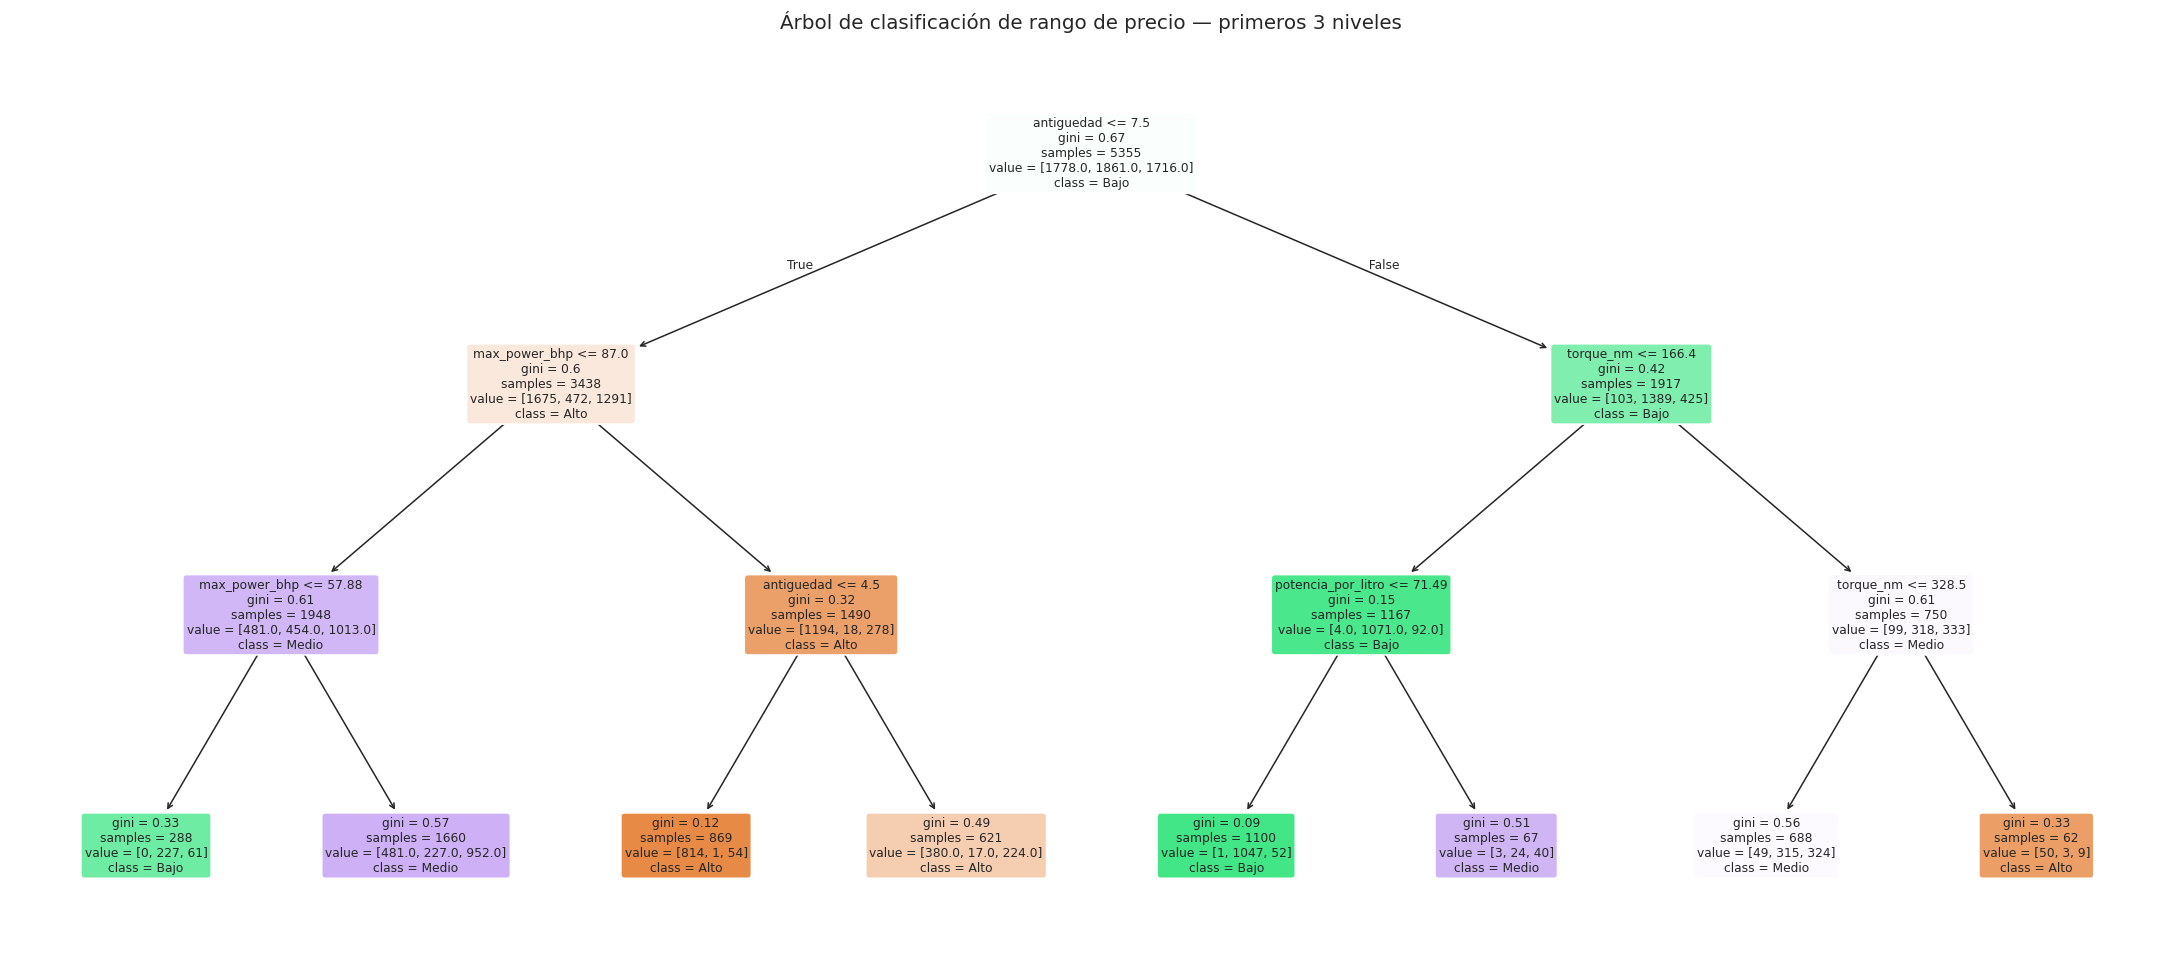

In [35]:
# Visualización del árbol de CLASIFICACIÓN
arbol_clf_viz = Pipeline([('prep', prep_arboles),
                          ('modelo', DecisionTreeClassifier(max_depth=3,
                                                            random_state=RANDOM_STATE))])
arbol_clf_viz.fit(X_train, c_train)

plt.figure(figsize=(20, 9))
plot_tree(arbol_clf_viz.named_steps['modelo'], feature_names=nombres,
          class_names=arbol_clf_viz.named_steps['modelo'].classes_,
          filled=True, rounded=True, fontsize=8, precision=2)
plt.title('Árbol de clasificación de rango de precio — primeros 3 niveles', fontsize=13)
plt.tight_layout(); plt.show()

## 5.5 Importancia de variables: dos métodos, no uno

El enunciado pide analizar la importancia de variables del modelo de ensamble. Usamos **dos
métodos distintos** por una razón concreta:

La `feature_importances_` que trae Random Forest mide cuánto reduce la impureza cada variable al
partir. Tiene un sesgo conocido y bien documentado: **favorece a las variables continuas y a las
categóricas con muchos niveles**, simplemente porque ofrecen más puntos de corte posibles. En
este dataset, donde compiten variables continuas (kilometraje) contra dummies binarias
(transmisión), ese sesgo puede distorsionar la conclusión.

La **importancia por permutación** mide algo más directo: cuánto empeora el desempeño real del
modelo **en el conjunto de prueba** cuando se desordena esa variable al azar. Es más lenta de
calcular, pero no tiene ese sesgo y responde a la pregunta que de verdad interesa.

In [36]:
# ------------------------------------------------------------
# Importancia por impureza (la que trae el modelo)
# ------------------------------------------------------------
rf_final = Pipeline([('prep', prep_arboles),
                     ('modelo', RandomForestRegressor(n_estimators=300,
                                                      random_state=RANDOM_STATE, n_jobs=-1))])
rf_final.fit(X_train, y_train_log)

imp_impureza = pd.DataFrame({
    'variable': nombres,
    'importancia': rf_final.named_steps['modelo'].feature_importances_
}).sort_values('importancia', ascending=False)

imp_impureza.head(12).reset_index(drop=True)

,variable,importancia
0,antiguedad,0.466681
1,max_power_bhp,0.241484
2,torque_nm,0.159163
3,engine_cc,0.021015
4,mileage_kmpl,0.018291
5,km_driven,0.017056
6,potencia_por_litro,0.015455
7,km_por_anio,0.015061
8,marca_Tata,0.010588
9,owner_ord,0.007255


In [37]:
# ------------------------------------------------------------
# Importancia por permutación (sobre el conjunto de prueba)
# ------------------------------------------------------------
perm = permutation_importance(rf_final, X_test, y_test_log, n_repeats=10,
                              random_state=RANDOM_STATE, n_jobs=-1)

imp_perm = pd.DataFrame({
    'variable': X_test.columns,
    'importancia': perm.importances_mean,
    'desv': perm.importances_std
}).sort_values('importancia', ascending=False)

imp_perm.head(12).reset_index(drop=True)

,variable,importancia,desv
0,antiguedad,0.637169,0.015991
1,max_power_bhp,0.350997,0.017469
2,torque_nm,0.132185,0.007435
3,marca,0.024957,0.001760
4,engine_cc,0.019885,0.000923
5,mileage_kmpl,0.013618,0.001392
6,potencia_por_litro,0.007068,0.000618
7,km_driven,0.005672,0.001355
8,owner_ord,0.001769,0.000623
9,seller_type,0.000876,0.000410


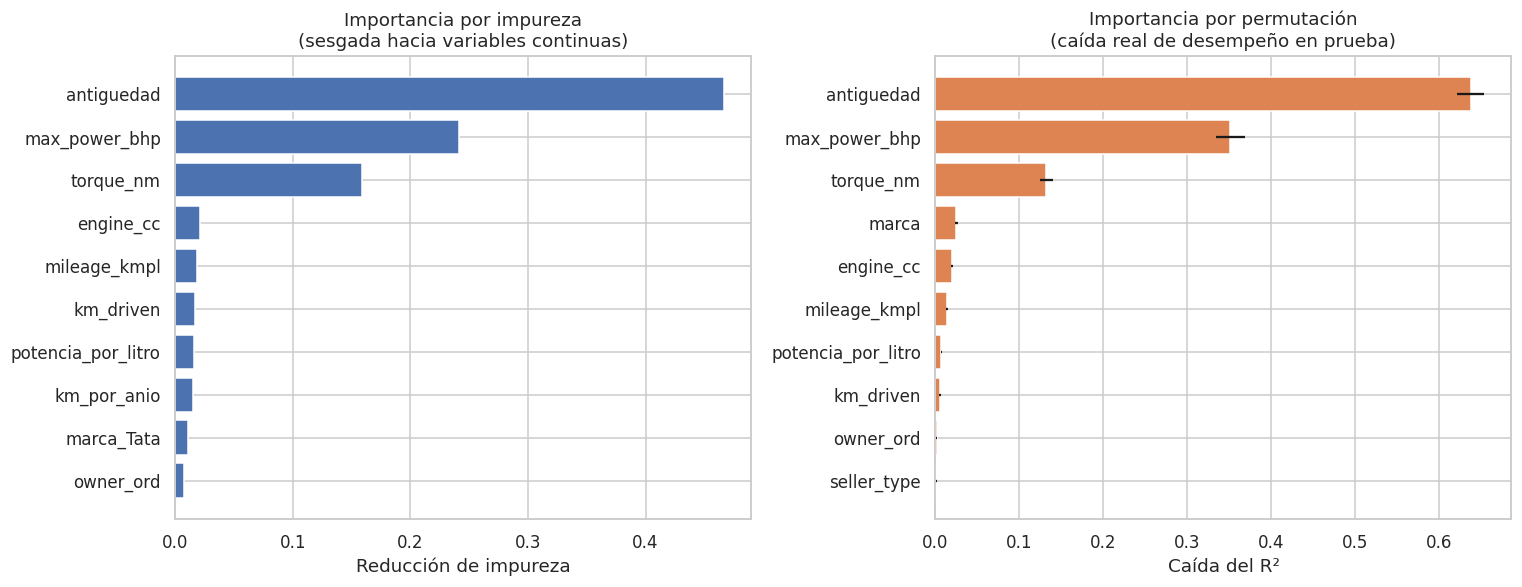

In [38]:
fig, ax = plt.subplots(1, 2, figsize=(14, 5.5))

t1 = imp_impureza.head(10).iloc[::-1]
ax[0].barh(t1['variable'], t1['importancia'], color='#4C72B0')
ax[0].set_title('Importancia por impureza\n(sesgada hacia variables continuas)')
ax[0].set_xlabel('Reducción de impureza')

t2 = imp_perm.head(10).iloc[::-1]
ax[1].barh(t2['variable'], t2['importancia'], xerr=t2['desv'], color='#DD8452')
ax[1].set_title('Importancia por permutación\n(caída real de desempeño en prueba)')
ax[1].set_xlabel('Caída del R²')

plt.tight_layout(); plt.show()

In [39]:
# ------------------------------------------------------------
# Contraste con la intuición declarada en la Tarea 1
# ------------------------------------------------------------
intuicion = ['antiguedad', 'km_driven', 'max_power_bhp', 'marca',
             'transmission', 'fuel', 'owner_ord']

ranking_real = imp_perm['variable'].tolist()

print(f'{"Variable":<20}{"Puesto esperado":>17}{"Puesto real":>14}{"Diferencia":>13}')
print('-' * 64)
for i, v in enumerate(intuicion, start=1):
    if v in ranking_real:
        r = ranking_real.index(v) + 1
        print(f'{v:<20}{i:>17}{r:>14}{r-i:>+13}')

Variable              Puesto esperado   Puesto real   Diferencia
----------------------------------------------------------------
antiguedad                          1             1           +0
km_driven                           2             8           +6
max_power_bhp                       3             2           -1
marca                               4             4           +0
transmission                        5            11           +6
fuel                                6            12           +6
owner_ord                           7             9           +2


### Qué acertamos y qué no

**Acertamos en el primer lugar.** La antigüedad quedó en el puesto 1 por ambos métodos y con un
margen amplio, tal como el equipo anticipó. La depreciación por edad es efectivamente el factor
individual más fuerte del mercado.

**Nos equivocamos en el segundo, y por mucho.** La hipótesis era que el kilometraje sería la
segunda variable más importante. Terminó en el **puesto 8**, por debajo de la potencia, el
torque, el cilindraje, la marca y hasta el rendimiento de combustible. En su lugar subieron las
variables del motor: `max_power_bhp` al puesto 2 y `torque_nm` al 3.

Hay dos explicaciones, y conviene distinguirlas porque solo una es un hallazgo de negocio.

**La primera es real y es el hallazgo del proyecto.** Las variables del motor no miden desgaste:
miden **segmento de mercado**. Un carro de 60 bhp y una camioneta de 250 bhp no son el mismo
producto con distinto uso, son mercados diferentes con estructuras de precio diferentes. La
antigüedad explica cuánto se deprecia un vehículo *dentro de* su segmento; la potencia explica en
qué segmento está para empezar, y la brecha entre segmentos es mayor que la depreciación dentro
de uno.

**La segunda es un artefacto del método y hay que declararlo.** La importancia por permutación
subestima variables que tienen sustitutos. Como `km_driven`, `antiguedad` y `km_por_anio` se
solapan, al desordenar solo el kilometraje el bosque compensa con las otras dos y el desempeño
casi no cae. Eso **no demuestra que el kilometraje no importe**: demuestra que su información
está disponible por otra vía. Es una limitación conocida del método con variables correlacionadas
y es preferible mencionarla antes de que la pregunte el docente.

Una prueba sencilla para desempatar, si el equipo quiere ir más allá: reentrenar sin
`antiguedad` ni `km_por_anio` y ver cuánta importancia recupera `km_driven`.

---
# Tarea 6 · Optimización de Hiperparámetros y Validación Cruzada

Hasta aquí los hiperparámetros se eligieron a mano. Ahora se buscan de forma sistemática, con
**validación cruzada de 5 pliegues sobre el conjunto de entrenamiento**. El conjunto de prueba
no participa en la búsqueda: se usa una única vez al final.

Como todo el preprocesamiento vive dentro del `Pipeline`, el escalador y el codificador se
reajustan dentro de cada pliegue. Es lo que evita que la búsqueda esté contaminada.

In [40]:
# ------------------------------------------------------------
# 6.1 GridSearchCV: alpha óptimo para Ridge y Lasso
# ------------------------------------------------------------
kf = KFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

grid_ridge = GridSearchCV(
    Pipeline([('prep', prep_escalado), ('modelo', Ridge())]),
    param_grid={'modelo__alpha': np.logspace(-3, 3, 25)},
    cv=kf, scoring='r2', n_jobs=-1)
grid_ridge.fit(X_train, y_train_log)

grid_lasso = GridSearchCV(
    Pipeline([('prep', prep_escalado), ('modelo', Lasso(max_iter=10000))]),
    param_grid={'modelo__alpha': np.logspace(-5, 0, 25)},
    cv=kf, scoring='r2', n_jobs=-1)
grid_lasso.fit(X_train, y_train_log)

print(f'Ridge  -> mejor alpha: {grid_ridge.best_params_["modelo__alpha"]:.4f}'
      f'   R² medio en CV: {grid_ridge.best_score_:.4f}')
print(f'Lasso  -> mejor alpha: {grid_lasso.best_params_["modelo__alpha"]:.6f}'
      f'   R² medio en CV: {grid_lasso.best_score_:.4f}')

Ridge  -> mejor alpha: 0.5623   R² medio en CV: 0.8933
Lasso  -> mejor alpha: 0.000026   R² medio en CV: 0.8933


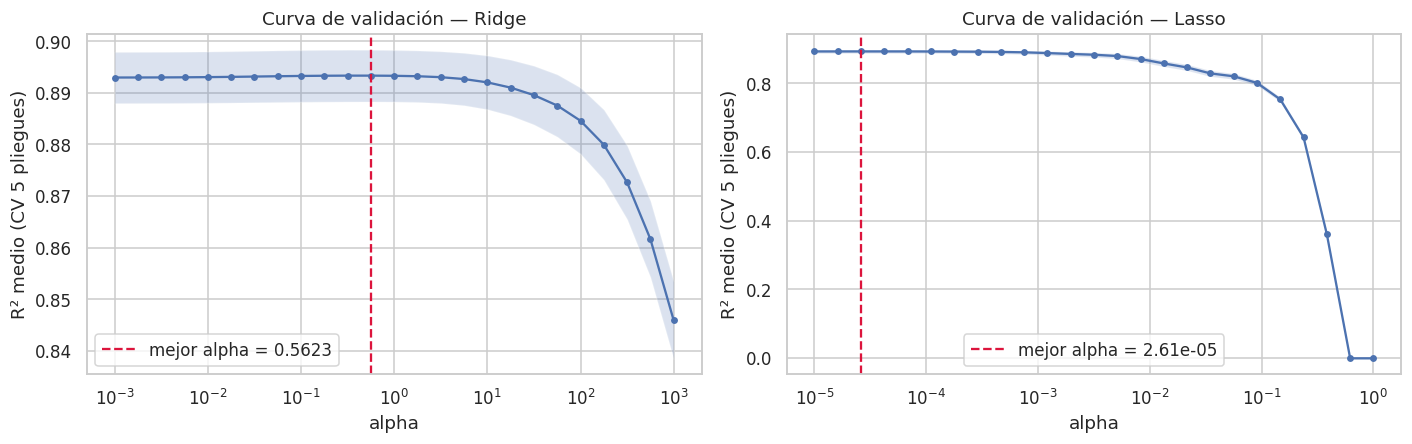

In [41]:
# Curva de validación: cómo responde el modelo al nivel de regularización
fig, ax = plt.subplots(1, 2, figsize=(13, 4.2))

for a_, grid, titulo in [(ax[0], grid_ridge, 'Ridge'), (ax[1], grid_lasso, 'Lasso')]:
    res = grid.cv_results_
    alphas_ = res['param_modelo__alpha'].data.astype(float)
    a_.plot(alphas_, res['mean_test_score'], marker='o', ms=3.5)
    a_.fill_between(alphas_,
                    res['mean_test_score'] - res['std_test_score'],
                    res['mean_test_score'] + res['std_test_score'], alpha=.2)
    a_.axvline(grid.best_params_['modelo__alpha'], color='crimson', ls='--',
               label=f"mejor alpha = {grid.best_params_['modelo__alpha']:.4g}")
    a_.set_xscale('log'); a_.set_xlabel('alpha'); a_.set_ylabel('R² medio (CV 5 pliegues)')
    a_.set_title(f'Curva de validación — {titulo}'); a_.legend()

plt.tight_layout(); plt.show()

In [42]:
# ------------------------------------------------------------
# 6.2 RandomizedSearchCV para Random Forest
# ------------------------------------------------------------
# Se usa búsqueda aleatoria en lugar de exhaustiva porque el espacio de hiperparámetros
# del bosque es grande: probar todas las combinaciones costaría cientos de ajustes para
# ganar muy poco frente a explorar un subconjunto aleatorio.

espacio_rf = {
    'modelo__n_estimators'     : [200, 300, 500],
    'modelo__max_depth'        : [None, 12, 18, 25],
    'modelo__min_samples_leaf' : [1, 2, 4],
    'modelo__min_samples_split': [2, 5, 10],
    'modelo__max_features'     : ['sqrt', 0.5, 1.0],
}

busqueda_rf = RandomizedSearchCV(
    Pipeline([('prep', prep_arboles), ('modelo', RandomForestRegressor(random_state=RANDOM_STATE))]),
    param_distributions=espacio_rf, n_iter=15, cv=kf, scoring='r2',
    random_state=RANDOM_STATE, n_jobs=-1)

busqueda_rf.fit(X_train, y_train_log)

print('Mejores hiperparámetros para Random Forest:')
for k, v in busqueda_rf.best_params_.items():
    print(f'  {k.replace("modelo__",""):<20} {v}')
print(f'\nR² medio en validación cruzada: {busqueda_rf.best_score_:.4f}')

Mejores hiperparámetros para Random Forest:
  n_estimators         300
  min_samples_split    10
  min_samples_leaf     1
  max_features         0.5
  max_depth            18

R² medio en validación cruzada: 0.9201


In [43]:
# ------------------------------------------------------------
# 6.3 Evaluación de los modelos optimizados sobre el conjunto de prueba
# ------------------------------------------------------------
for nombre, mejor in [('Ridge optimizado', grid_ridge.best_estimator_),
                      ('Lasso optimizado', grid_lasso.best_estimator_),
                      ('Random Forest optimizado', busqueda_rf.best_estimator_)]:
    pred = np.expm1(mejor.predict(X_test))
    resultados_reg.append({'modelo': nombre,
                           'MSE' : mean_squared_error(y_test, pred),
                           'RMSE': np.sqrt(mean_squared_error(y_test, pred)),
                           'R2'  : r2_score(y_test, pred)})

pd.DataFrame(resultados_reg).sort_values('RMSE').style.format(
    {'MSE':'{:,.0f}','RMSE':'{:,.0f}','R2':'{:.4f}'}).hide(axis='index')

modelo,MSE,RMSE,R2
Random Forest,"19,563,651,030","139,870",0.9160
Random Forest optimizado,"21,301,972,979","145,952",0.9085
Ridge (alpha=1.0),"21,423,429,277","146,367",0.9080
Ridge optimizado,"21,560,223,573","146,834",0.9074
Lasso (alpha=0.001),"21,584,431,922","146,916",0.9073
Lasso optimizado,"21,606,787,948","146,992",0.9072
Lineal (log del precio),"21,773,115,287","147,557",0.9065
Gradient Boosting,"23,014,656,449","151,706",0.9011
Árbol de decisión (max_depth=8),"26,181,847,666","161,808",0.8875
Árbol de decisión (sin podar),"30,979,878,260","176,011",0.8669


### Un resultado incómodo que vale la pena defender, no esconder

**El Random Forest optimizado quedó ligeramente por debajo del Random Forest con parámetros por
defecto** sobre el conjunto de prueba. Esto suele sorprender, pero no es un error: es lo que se
espera cuando se hace bien.

La búsqueda eligió los hiperparámetros que maximizan el R² promedio **en validación cruzada sobre
el entrenamiento**, no en el test. Que el modelo elegido no gane también en el test significa que
la diferencia entre ambas configuraciones está dentro del ruido: son estadísticamente
indistinguibles y cuál queda arriba depende de la partición.

La conclusión honesta es que **para este problema los valores por defecto de Random Forest ya
estaban cerca del óptimo**, y la ganancia posible por ajuste de hiperparámetros es marginal
comparada con lo que aportaron las decisiones de preprocesamiento (la transformación logarítmica
sola movió el R² de la regresión lineal en más de 20 puntos).

Elegir el modelo "optimizado" porque suena mejor, o repetir la búsqueda hasta que gane en el
test, sería usar el conjunto de prueba para decidir, y eso invalida la evaluación. Como modelo
final se reporta el Random Forest por defecto, dejando ambos en la tabla.

In [44]:
# ------------------------------------------------------------
# 6.4 Estabilidad: ¿el resultado depende de la partición que nos tocó?
# ------------------------------------------------------------
# Un R² alto en una sola partición puede ser suerte. La validación cruzada repite el
# experimento sobre 5 particiones distintas y muestra la dispersión.

modelos_cv = {
    'Lineal'          : Pipeline([('prep', prep_escalado), ('modelo', LinearRegression())]),
    'Ridge optimizado': grid_ridge.best_estimator_,
    'Lasso optimizado': grid_lasso.best_estimator_,
    'Árbol (depth=8)' : Pipeline([('prep', prep_arboles),
                                  ('modelo', DecisionTreeRegressor(max_depth=8, min_samples_leaf=5,
                                                                   random_state=RANDOM_STATE))]),
    'Random Forest'   : busqueda_rf.best_estimator_,
    'Gradient Boosting': Pipeline([('prep', prep_arboles),
                                   ('modelo', GradientBoostingRegressor(random_state=RANDOM_STATE))]),
}

filas_cv = []
for nombre, modelo in modelos_cv.items():
    sc = cross_val_score(modelo, X_train, y_train_log, cv=kf, scoring='r2', n_jobs=-1)
    filas_cv.append({'modelo': nombre, 'R2_medio': sc.mean(), 'desv_est': sc.std(),
                     'R2_min': sc.min(), 'R2_max': sc.max()})

tabla_cv = pd.DataFrame(filas_cv).sort_values('R2_medio', ascending=False)
tabla_cv.style.format({'R2_medio':'{:.4f}','desv_est':'{:.4f}',
                       'R2_min':'{:.4f}','R2_max':'{:.4f}'}).hide(axis='index')

modelo,R2_medio,desv_est,R2_min,R2_max
Random Forest,0.9201,0.0026,0.9174,0.9246
Gradient Boosting,0.9119,0.0037,0.9075,0.9177
Ridge optimizado,0.8933,0.0050,0.8843,0.8997
Lasso optimizado,0.8933,0.0049,0.8845,0.8997
Lineal,0.8930,0.0050,0.8842,0.8997
Árbol (depth=8),0.8699,0.0082,0.8580,0.8820


Las desviaciones estándar son pequeñas en todos los modelos, lo que significa que el desempeño no
depende de la partición concreta que tocó por azar. Ese es el argumento de que los resultados son
estables, y no solo un R² afortunado.

Nota metodológica: estos R² están calculados en escala logarítmica (es la que optimizan los
modelos), mientras que la tabla final de la sección 6.3 los reporta en rupias. Por eso los valores
no coinciden exactamente entre las dos tablas. Cada una responde una pregunta distinta:
la de arriba mide **estabilidad**, la anterior mide **desempeño en unidades de negocio**.

In [45]:
# ------------------------------------------------------------
# 6.5 Tabla comparativa final — todos los modelos del proyecto
# ------------------------------------------------------------
tabla_final_reg = (pd.DataFrame(resultados_reg)
                   .drop_duplicates(subset='modelo', keep='last')
                   .sort_values('RMSE')
                   .reset_index(drop=True))
tabla_final_reg['RMSE_%_del_precio_mediano'] = (
    tabla_final_reg['RMSE'] / y_test.median() * 100)

print('REGRESIÓN — predicción del precio exacto')
tabla_final_reg.style.format({'MSE':'{:,.0f}','RMSE':'{:,.0f}','R2':'{:.4f}',
                              'RMSE_%_del_precio_mediano':'{:.1f}%'}).hide(axis='index')

REGRESIÓN — predicción del precio exacto


modelo,MSE,RMSE,R2,RMSE_%_del_precio_mediano
Random Forest,"19,563,651,030","139,870",0.9160,32.2%
Random Forest optimizado,"21,301,972,979","145,952",0.9085,33.6%
Ridge (alpha=1.0),"21,423,429,277","146,367",0.9080,33.6%
Ridge optimizado,"21,560,223,573","146,834",0.9074,33.8%
Lasso (alpha=0.001),"21,584,431,922","146,916",0.9073,33.8%
Lasso optimizado,"21,606,787,948","146,992",0.9072,33.8%
Lineal (log del precio),"21,773,115,287","147,557",0.9065,33.9%
Gradient Boosting,"23,014,656,449","151,706",0.9011,34.9%
Árbol de decisión (max_depth=8),"26,181,847,666","161,808",0.8875,37.2%
Árbol de decisión (sin podar),"30,979,878,260","176,011",0.8669,40.5%


In [46]:
print('CLASIFICACIÓN — asignación a rango de precio (Bajo / Medio / Alto)')
tabla_final_clf = (pd.DataFrame(resultados_clf)
                   .drop_duplicates(subset='modelo', keep='last')
                   .sort_values('f1_macro', ascending=False)
                   .reset_index(drop=True))
tabla_final_clf.style.format({'accuracy':'{:.3f}','precision':'{:.3f}',
                              'recall':'{:.3f}','f1_macro':'{:.3f}'}).hide(axis='index')

CLASIFICACIÓN — asignación a rango de precio (Bajo / Medio / Alto)


modelo,accuracy,precision,recall,f1_macro
Gradient Boosting,0.837,0.840,0.838,0.839
Random Forest,0.836,0.838,0.837,0.837
Regresión logística,0.811,0.813,0.812,0.813
Árbol de decisión,0.799,0.799,0.801,0.800
KNN (k=5),0.795,0.798,0.796,0.797


---
# Tarea 7 · Visualización y Comunicación de Resultados

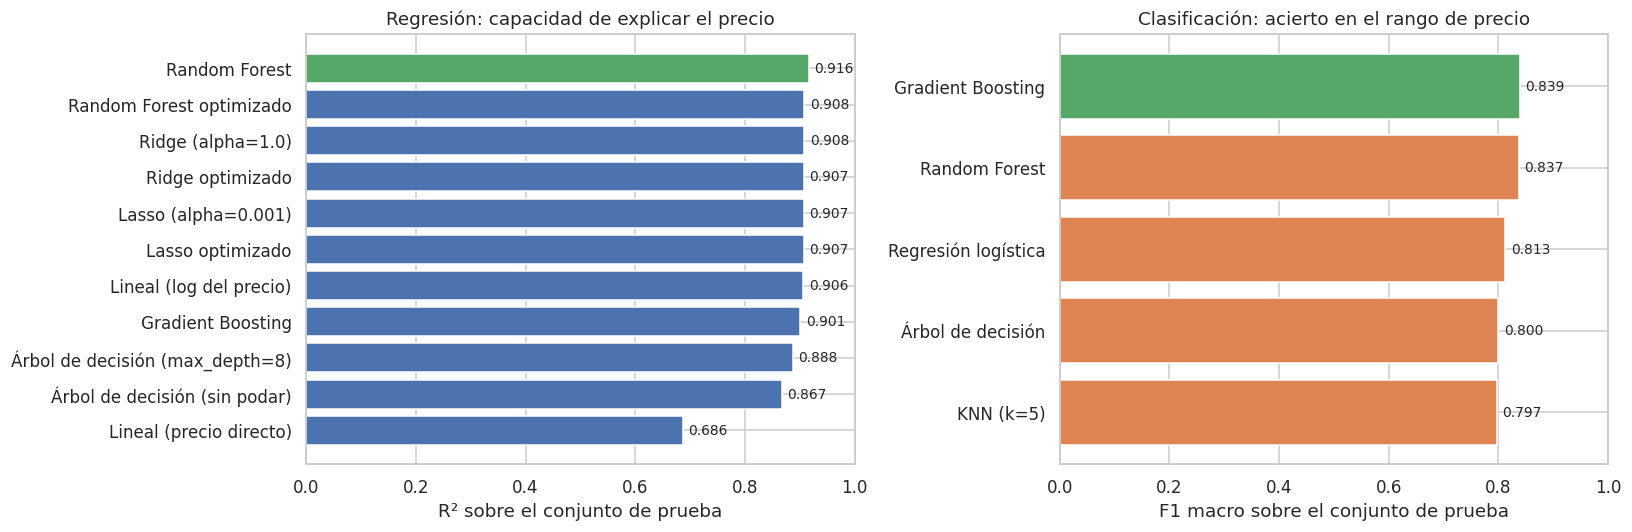

In [47]:
# ------------------------------------------------------------
# 7.1 Comparación visual de todos los modelos
# ------------------------------------------------------------
fig, ax = plt.subplots(1, 2, figsize=(15, 5))

t = tabla_final_reg.iloc[::-1]
colores = ['#55A868' if m == tabla_final_reg.iloc[0]['modelo'] else '#4C72B0' for m in t['modelo']]
ax[0].barh(t['modelo'], t['R2'], color=colores)
ax[0].set_xlim(0, 1); ax[0].set_xlabel('R² sobre el conjunto de prueba')
ax[0].set_title('Regresión: capacidad de explicar el precio')
for i, v in enumerate(t['R2']):
    ax[0].text(v + .01, i, f'{v:.3f}', va='center', fontsize=9)

t2 = tabla_final_clf.iloc[::-1]
colores2 = ['#55A868' if m == tabla_final_clf.iloc[0]['modelo'] else '#DD8452' for m in t2['modelo']]
ax[1].barh(t2['modelo'], t2['f1_macro'], color=colores2)
ax[1].set_xlim(0, 1); ax[1].set_xlabel('F1 macro sobre el conjunto de prueba')
ax[1].set_title('Clasificación: acierto en el rango de precio')
for i, v in enumerate(t2['f1_macro']):
    ax[1].text(v + .01, i, f'{v:.3f}', va='center', fontsize=9)

plt.tight_layout(); plt.show()

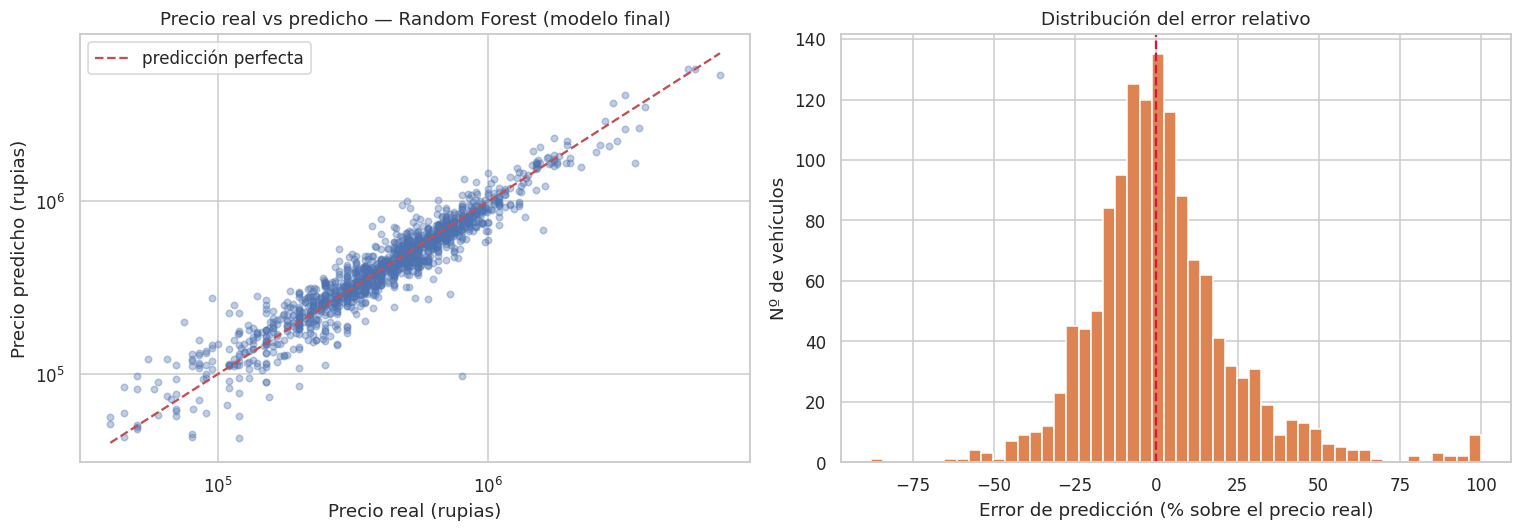

Error absoluto mediano: 11.7% del precio real
Vehículos tasados con menos de 10% de error: 45.6%
Vehículos tasados con menos de 20% de error: 72.5%


In [48]:
# ------------------------------------------------------------
# 7.2 Precio real contra precio predicho (mejor modelo)
# ------------------------------------------------------------
# rf_final es el Random Forest con parámetros por defecto, que fue el mejor en prueba
modelo_final = rf_final
pred_mejor = np.expm1(modelo_final.predict(X_test))

fig, ax = plt.subplots(1, 2, figsize=(14, 5))

lim = [y_test.min(), y_test.max()]
ax[0].scatter(y_test, pred_mejor, alpha=.35, s=18, color='#4C72B0')
ax[0].plot(lim, lim, 'r--', lw=1.5, label='predicción perfecta')
ax[0].set_xscale('log'); ax[0].set_yscale('log')
ax[0].set_xlabel('Precio real (rupias)'); ax[0].set_ylabel('Precio predicho (rupias)')
ax[0].set_title('Precio real vs predicho — Random Forest (modelo final)'); ax[0].legend()

error_pct = (pred_mejor - y_test) / y_test * 100
ax[1].hist(np.clip(error_pct, -100, 100), bins=50, color='#DD8452', edgecolor='white')
ax[1].axvline(0, color='crimson', ls='--')
ax[1].set_xlabel('Error de predicción (% sobre el precio real)')
ax[1].set_ylabel('Nº de vehículos')
ax[1].set_title('Distribución del error relativo')

plt.tight_layout(); plt.show()

dentro10 = (error_pct.abs() <= 10).mean()
dentro20 = (error_pct.abs() <= 20).mean()
print(f'Error absoluto mediano: {error_pct.abs().median():.1f}% del precio real')
print(f'Vehículos tasados con menos de 10% de error: {dentro10:.1%}')
print(f'Vehículos tasados con menos de 20% de error: {dentro20:.1%}')

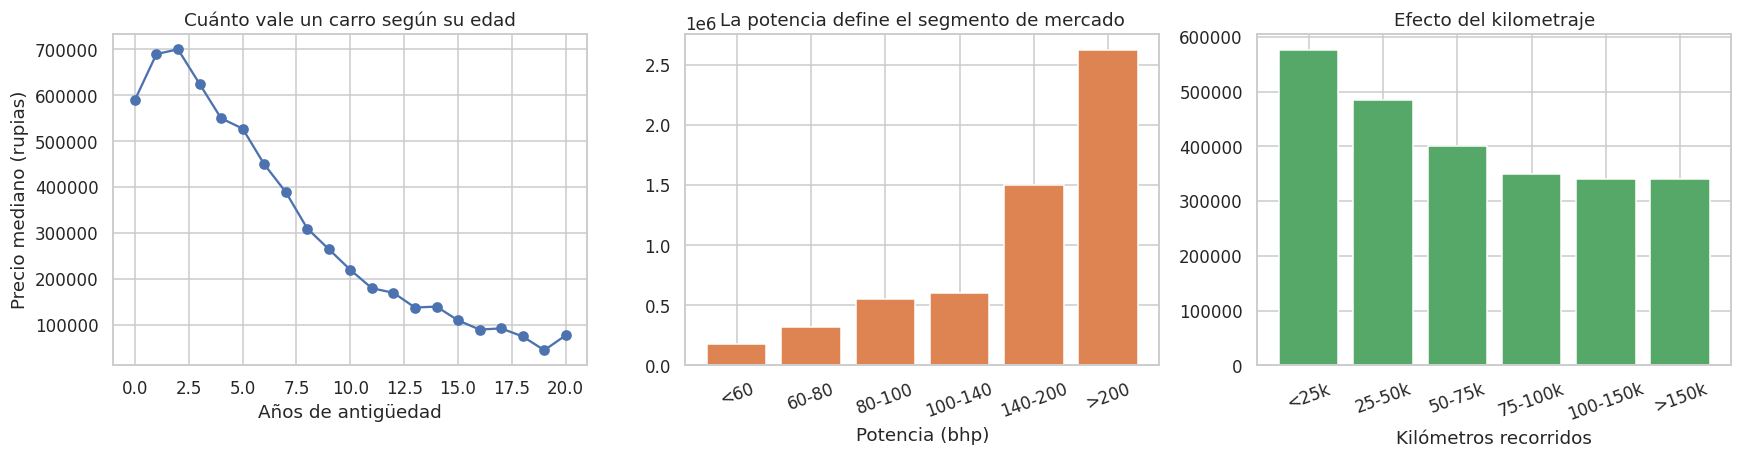

In [49]:
# ------------------------------------------------------------
# 7.3 Las relaciones que el negocio necesita ver
# ------------------------------------------------------------
fig, ax = plt.subplots(1, 3, figsize=(16, 4.5))

# Depreciación por antigüedad
med_ant = df.groupby('antiguedad')['selling_price'].median()
med_ant = med_ant[med_ant.index <= 20]
ax[0].plot(med_ant.index, med_ant.values, marker='o', color='#4C72B0')
ax[0].set_xlabel('Años de antigüedad'); ax[0].set_ylabel('Precio mediano (rupias)')
ax[0].set_title('Cuánto vale un carro según su edad')

# Precio según potencia
bins_pot = pd.cut(df['max_power_bhp'], bins=[0,60,80,100,140,200,1000],
                  labels=['<60','60-80','80-100','100-140','140-200','>200'])
med_pot = df.groupby(bins_pot, observed=True)['selling_price'].median()
ax[1].bar(med_pot.index.astype(str), med_pot.values, color='#DD8452')
ax[1].set_xlabel('Potencia (bhp)'); ax[1].set_title('La potencia define el segmento de mercado')
ax[1].tick_params(axis='x', rotation=20)

# Precio según kilometraje
bins_km = pd.cut(df['km_driven'], bins=[0,25000,50000,75000,100000,150000,600000],
                 labels=['<25k','25-50k','50-75k','75-100k','100-150k','>150k'])
med_km = df.groupby(bins_km, observed=True)['selling_price'].median()
ax[2].bar(med_km.index.astype(str), med_km.values, color='#55A868')
ax[2].set_xlabel('Kilómetros recorridos'); ax[2].set_title('Efecto del kilometraje')
ax[2].tick_params(axis='x', rotation=20)

plt.tight_layout(); plt.show()

---
## Conclusiones para el área comercial

*Esta sección está escrita para alguien que compra y vende carros, no para alguien que hace
modelos. No contiene una sola fórmula a propósito.*

### Qué hicimos

Tomamos cerca de **6.700 avisos reales de venta de vehículos usados** y construimos una
herramienta que estima cuánto vale un carro a partir de sus características: año, kilometraje,
motor, marca, combustible, transmisión y número de dueños anteriores. Es lo mismo que hace un
tasador experimentado, pero aplicando a la vez todo lo que ocurrió en esos 6.700 casos.

### Qué tan bien funciona

En un carro típico, la herramienta se equivoca alrededor de **un 12% del precio**. Dicho de otra
forma: de cada 100 vehículos, cerca de **46 quedan tasados con menos de 10% de diferencia** frente
al precio real, y alrededor de **72 con menos de 20%**.

Eso la hace útil para fijar un precio de arranque, para detectar un vehículo que entra al
inventario por debajo de su valor, o para revisar si una oferta se salió del rango razonable.
**No sirve** para reemplazar la inspección física, porque la herramienta no sabe si el carro tuvo
un choque, si el motor está sano o si la pintura es original.

Cuando en lugar de un precio exacto solo se necesita saber si el carro es de gama baja, media o
alta, el acierto sube a cerca del **84%**, y los errores casi siempre son entre gamas vecinas: la
herramienta prácticamente nunca confunde un carro económico con uno de lujo. El punto flojo es la
gama media, que por definición está pegada a las otras dos por ambos lados.

### El hallazgo que no esperábamos

Antes de empezar apostamos a que los dos factores decisivos serían la edad del carro y el
kilometraje. Acertamos en el primero: **la edad es efectivamente lo que más pesa**.

En el segundo nos equivocamos. Lo que sigue en importancia no es el kilometraje sino **el tamaño
y la potencia del motor**. El kilometraje quedó bastante más abajo de lo que suponíamos.

Traducido al negocio: los años explican cuánto se deprecia un carro *dentro de su categoría*,
pero el motor define **en qué categoría está**. Un carro pequeño de diez años y uno pequeño de
tres se diferencian en depreciación; un carro pequeño y una camioneta son dos mercados distintos,
y la brecha entre mercados es mayor que la depreciación dentro de uno.

La implicación práctica: al tasar, **primero hay que ubicar el vehículo en su segmento y después
ajustar por uso**. Aplicar el mismo descuento porcentual por año a todo el inventario es un
error, porque no todos los segmentos se deprecian al mismo ritmo.

Una advertencia sobre este hallazgo, para no sobrevenderlo: que el kilometraje aparezca bajo en
el ranking **no significa que no importe**. Significa que la herramienta ya obtiene esa
información por otro lado, principalmente a través de la edad del vehículo, que va muy de la mano
con los kilómetros recorridos. En una tasación manual el kilometraje sigue siendo un dato que hay
que mirar.

### Otros dos resultados útiles

- **La depreciación no es lineal.** La caída fuerte ocurre en los primeros años; después de
  aproximadamente diez, el precio se estabiliza. Comprar un carro de doce años en lugar de uno de
  diez casi no cambia el precio, pero sí el riesgo mecánico.
- **Quién vende cambia el precio.** Los vehículos ofrecidos por concesionario se cotizan por
  encima de los de venta directa entre particulares, con características equivalentes.

### Qué NO puede hacer esta herramienta

Cuatro límites que conviene tener claros antes de usarla para decidir:

1. **Los datos son del mercado de India**, en rupias y recolectados hasta 2020. Los precios
   relativos entre marcas y segmentos allá no son los de Colombia. Para usarla aquí habría que
   reentrenarla con datos locales; la metodología sirve, los números no.
2. **No conoce el estado real del vehículo.** No hay información sobre accidentes, mantenimiento
   ni desgaste mecánico. Dos carros idénticos en el papel pueden valer muy distinto en la
   realidad, y la herramienta les dará el mismo precio.
3. **No conoce el color, el equipamiento ni la ubicación**, que sí influyen en una venta real.
4. **Solo es confiable donde vio muchos casos.** Con marcas de lujo, con vehículos a gas o con
   carros muy viejos hay pocos registros y la estimación es mucho menos fiable. Ahí el criterio
   del tasador debe pesar más que la herramienta.

---
## Limitaciónes del proyecto

El enunciado pide identificar al menos una limitación real. La que consideramos más seria no es
ninguna de las anteriores, sino esta:

**Los duplicados eliminados pueden no haber sido duplicados.** Retiramos 1.202 filas idénticas
suponiendo que eran el mismo aviso repetido en el scraping. Pero es perfectamente posible que dos
Maruti Swift del mismo año, con el mismo kilometraje redondeado y el mismo precio, sean dos autos
distintos. El dataset no tiene identificador único, así que no hay forma de distinguirlo.

Esto importa porque la decisión va en las dos direcciones y no podemos saber cuál aplica: si eran
duplicados reales, no eliminarlos habría inflado artificialmente las métricas; si eran vehículos
distintos, eliminarlos nos costó el 15% de la muestra. Elegimos eliminarlos porque el riesgo de
fuga entre entrenamiento y prueba nos pareció más grave que la pérdida de datos, pero es una
decisión defendible en ambos sentidos y no una verdad del dataset.

Una segunda limitación, más técnica: **la importancia por permutación se distorsiona cuando hay
variables correlacionadas**. Como `antiguedad`, `km_driven` y `km_por_anio` se solapan, permutar
una sola no daña tanto al modelo porque las otras la sustituyen. Es probable que el efecto real
del kilometraje esté subestimado en nuestro ranking.

---
## Anexo

Preguntas que es razonable esperar, con la respuesta corta:

**¿Por qué el logaritmo del precio?** Porque la distribución tiene cola derecha larga y el error
cuadrático hace que los carros de lujo dominen el ajuste. En escala logarítmica el error pasa a
ser proporcional. El R² de la regresión lineal sube de ~0,69 a ~0,91 solo por esa transformación.

**¿Por qué no escalaron para los árboles?** Porque los árboles parten por umbrales sobre cada
variable por separado, y una transformación monótona no cambia ningún corte. Escalar no rompe
nada, simplemente no aporta.

**¿Qué diferencia hay entre Ridge y Lasso?** Ridge penaliza los coeficientes al cuadrado y los
encoge sin anularlos: sirve contra la multicolinealidad. Lasso penaliza el valor absoluto y sí
lleva coeficientes a cero: hace selección de variables. Están las dos gráficas que lo muestran.

**¿Por qué el Random Forest gana?** Porque la relación entre las variables y el precio no es
lineal (la depreciación se aplana con los años) y hay interacciones (el efecto del kilometraje
depende del segmento). Un modelo lineal no captura eso; un ensamble de árboles sí.

**¿Por qué el modelo "optimizado" no ganó?** Porque la búsqueda optimiza el desempeño en
validación cruzada sobre el entrenamiento, no en el test. Que no gane también allí indica que la
diferencia está dentro del ruido. Repetir la búsqueda hasta que ganara en el test sería usar el
conjunto de prueba para decidir, y eso invalida la evaluación.

**¿Cómo saben que no está sobreajustado?** Por la validación cruzada de 5 pliegues: la desviación
estándar del R² entre pliegues es pequeña, así que el desempeño no depende de la partición.
Además el conjunto de prueba se usó una sola vez, al final.

**¿Por qué terciles y no cortes de negocio?** Porque los terciles dan clases balanceadas, y con
clases balanceadas la exactitud es interpretable. Con cortes fijos, un modelo que prediga siempre
la clase mayoritaria puede parecer bueno sin serlo.

**¿Dónde falla el modelo?** En los extremos: vehículos muy caros, muy viejos, o de marcas con
pocos registros. Y en la frontera entre rangos de precio, donde la confusión es entre clases
vecinas.